# 🫀🦠 AI for Gut and Heart — Exploratory Data Analysis & Visualization

## Project Overview

**Research Question:** *Can dietary habits and lifestyle factors, as captured through the gut microbiome survey data, reveal patterns associated with cardiovascular and gastrointestinal health outcomes?*

### Why This Matters
- The **gut-heart axis** is an emerging area of research. Studies published in *Nature Medicine* (2019) and *JACC* (2020) have established that gut microbiome composition directly influences cardiovascular health through metabolites like **TMAO (Trimethylamine N-oxide)**.
- Diet is the **#1 modifiable risk factor** for both gut dysbiosis and heart disease (WHO, 2023).
- The American Gut Project is the **largest crowdsourced citizen science microbiome project** in the world, providing real-world data on diet, lifestyle, and health conditions.

### Dataset: American Gut Project
- **Source:** [biocore/American-Gut (GitHub)](https://github.com/biocore/American-Gut)
- **676 participants** (stool samples only — most relevant for gut-heart analysis)
- **48 features** covering demographics, diet, lifestyle, and health conditions
- Data has been pre-cleaned: `no_data` values replaced with NaN, irrelevant columns removed

### What This Notebook Does
1. **Data Loading & Initial Inspection** — Understand shape, types, missing values
2. **Missing Value Analysis** — Identify gaps and decide imputation strategy
3. **Univariate Analysis** — Distribution of individual features
4. **Bivariate Analysis** — Relationships between diet and health outcomes
5. **Correlation Analysis** — Heatmaps to find statistical associations
6. **Key Insights Summary** — Actionable findings for the ML phase

---

## 1. Setup & Data Loading

**Why these libraries?**
- `pandas` — Industry-standard for tabular data manipulation (used by 95% of data scientists)
- `numpy` — Numerical computing backbone; pandas is built on top of it
- `matplotlib` — Base plotting library; gives us full control over figure aesthetics
- `seaborn` — Built on matplotlib; provides statistical visualizations with less code
- `warnings` — Suppresses non-critical deprecation warnings to keep output clean

In [1]:
# ============================================================
# CELL 1: Import Libraries & Configure Display Settings
# ============================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

# Suppress non-critical warnings for cleaner notebook output
warnings.filterwarnings('ignore')

# Set global plot aesthetics
# WHY: Consistent, publication-quality plots throughout the notebook
# 'seaborn-v0_8-whitegrid' gives us a clean white background with subtle gridlines
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')  # HUSL palette provides perceptually uniform, colorblind-friendly colors
plt.rcParams['figure.figsize'] = (12, 6)  # Default figure size
plt.rcParams['font.size'] = 12
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

# Pandas display settings
pd.set_option('display.max_columns', 50)  # Show all 48 columns
pd.set_option('display.max_rows', 20)
pd.set_option('display.float_format', '{:.2f}'.format)  # 2 decimal places

print('All libraries loaded successfully!')
print(f'Pandas: {pd.__version__} | NumPy: {np.__version__}')

All libraries loaded successfully!
Pandas: 3.0.3 | NumPy: 2.5.1


In [2]:
# ============================================================
# CELL 2: Load the Cleaned Dataset
# ============================================================

# WHY we load from the pre-cleaned CSV:
# The raw American Gut dataset had 4,815 rows x 202 columns with tons of
# irrelevant columns (sequencing metadata, lab plate IDs, etc.).
# We pre-filtered to 676 stool samples with 48 health-relevant columns.

df = pd.read_csv(r'data/american_gut_clean.csv')

print(f'Dataset Shape: {df.shape[0]} rows x {df.shape[1]} columns')
print(f'Memory Usage: {df.memory_usage(deep=True).sum() / 1024:.1f} KB')
print(f'\nThis means we have {df.shape[0]} participant stool samples,')
print(f'each described by {df.shape[1]} features about their diet, lifestyle, and health.')

Dataset Shape: 676 rows x 48 columns
Memory Usage: 1464.1 KB

This means we have 676 participant stool samples,
each described by 48 features about their diet, lifestyle, and health.


In [3]:
# ============================================================
# CELL 3: First Look at the Data
# ============================================================

# WHY: Always inspect the first few rows to verify data loaded correctly
# and to get an intuitive feel for what each column represents.

print('--- First 5 Rows ---')
df.head()

--- First 5 Rows ---


,sample_id,participant_id,age,sex,bmi,height_inches,weight_lbs,race,country,state,diet_type,carb_percent,protein_percent,fat_percent,plant_percent,animal_percent,fiber_grams,primary_vegetable,primary_carb,percentage_from_carbs,types_of_plants,diet_restrictions,water_source,alcohol_frequency,smoking_frequency,exercise_frequency,exercise_location,sleep_duration,cosmetics_frequency,flossing_frequency,teethbrushing_frequency,ibd,diabetes,skin_condition,tonsils_removed,appendix_removed,c_section_birth,chickenpox,seasonal_allergies,lactose_intolerant,gluten_intolerant,antibiotic_history,supplements,multivitamin,weight_change,body_site,collection_date,sample_type
0,000015569.fixed647,15569,65.00,female,26.96,65.00,162.00,Caucasian,GAZ:United States of America,VERMONT,Omnivore,37.00,18.00,45.00,30.00,70.00,203.00,leafy greens,raspberries,51 to 75%,More than 30,NaN,Filtered,Daily,Never,Occasionally (1-2 times/week),Both,6-7 hours,Rarely (few times/month),Daily,Daily,NaN,I do not have diabetes,NaN,yes,no,yes,yes,yes,no,no,Not in the last year,yes,no,Remained stable,UBERON:feces,7/31/14,Stool
1,000011031.fixed716,11031,54.00,male,24.00,72.00,177.00,Caucasian,GAZ:United States of America,CA,Vegetarian but eat seafood,50.00,25.00,25.00,50.00,50.00,220.00,beans,Vegetables,Less than 25%,21 to 30,NaN,City,Daily,Never,Daily,Both,7-8 hours,Daily,Occasionally (1-2 times/week),Daily,I do not have IBD,I do not have diabetes,I do not have a skin condition,no,no,no,yes,no,no,no,Not in the last year,no,no,Remained stable,UBERON:feces,7/31/14,Stool
2,000016722.fixed480,16722,32.00,female,20.60,64.00,120.00,Caucasian,GAZ:United States of America,CO,Omnivore,52.00,20.00,28.00,15.00,85.00,84.00,kale,wheat,Less than 25%,More than 30,NaN,City,Never,Daily,Rarely (few times/month),Outdoors,7-8 hours,Occasionally (1-2 times/week),Regularly (3-5 times/week),Daily,I do not have IBD,I do not have diabetes,I do not have a skin condition,no,no,no,yes,no,no,no,Not in the last year,no,no,Remained stable,UBERON:feces,7/3/14,Stool
3,000016449.fixed444,16449,49.00,male,25.11,70.00,175.00,Caucasian,GAZ:United States of America,AK,Omnivore,20.00,30.00,50.00,50.00,50.00,350.00,potato,starch,Less than 25%,11 to 20,NaN,Well,NaN,NaN,Daily,Outdoors,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,no,no,Not in the last year,no,no,Remained stable,UBERON:feces,7/18/14,Stool
4,000018297.fixed577,18297,60.00,female,29.67,58.00,142.00,Caucasian,GAZ:United States of America,MASSACHUSETTS,Omnivore,20.00,20.00,60.00,0.00,100.00,NaN,spring salad greens,"vegetables - salad, broccoli, cauliflower",Less than 25%,Less than 5,NaN,City,Occasionally (1-2 times/week),Never,Regularly (3-5 times/week),Depends on the season,7-8 hours,Never,Daily,Daily,I do not have IBD,I do not have diabetes,I do not have a skin condition,no,no,no,yes,no,no,no,In the past 6 months,no,no,Increased more than 10 pounds,UBERON:feces,8/12/14,Stool


In [4]:
# ============================================================
# CELL 4: Data Types Overview
# ============================================================

# WHY: Understanding data types is CRITICAL before any analysis.
# - Numerical columns (float64/int64) -> can compute mean, std, correlations
# - Categorical columns (object/str) -> need encoding for ML, use bar charts for viz
# Wrong types = wrong analysis. E.g., if 'age' was stored as string, we couldn't compute averages.

print('=== Data Types ===' )
print(f'\nNumerical columns: {df.select_dtypes(include=["number"]).columns.tolist()}')
print(f'\nCategorical columns: {df.select_dtypes(include=["object"]).columns.tolist()}')
print(f'\n--- Counts ---')
print(f'Numerical: {len(df.select_dtypes(include=["number"]).columns)}')
print(f'Categorical: {len(df.select_dtypes(include=["object"]).columns)}')

=== Data Types ===

Numerical columns: ['participant_id', 'age', 'bmi', 'height_inches', 'weight_lbs', 'carb_percent', 'protein_percent', 'fat_percent', 'plant_percent', 'animal_percent', 'fiber_grams']

Categorical columns: ['sample_id', 'sex', 'race', 'country', 'state', 'diet_type', 'primary_vegetable', 'primary_carb', 'percentage_from_carbs', 'types_of_plants', 'diet_restrictions', 'water_source', 'alcohol_frequency', 'smoking_frequency', 'exercise_frequency', 'exercise_location', 'sleep_duration', 'cosmetics_frequency', 'flossing_frequency', 'teethbrushing_frequency', 'ibd', 'diabetes', 'skin_condition', 'tonsils_removed', 'appendix_removed', 'c_section_birth', 'chickenpox', 'seasonal_allergies', 'lactose_intolerant', 'gluten_intolerant', 'antibiotic_history', 'supplements', 'multivitamin', 'weight_change', 'body_site', 'collection_date', 'sample_type']

--- Counts ---
Numerical: 11
Categorical: 37


In [5]:
# ============================================================
# CELL 5: Statistical Summary of Numerical Columns
# ============================================================

# WHY: .describe() gives us the 5-number summary (min, Q1, median, Q3, max) plus mean & std.
# This immediately reveals:
#   - Outliers (e.g., BMI of 0 or 100 would be suspicious)
#   - Scale differences (age is 0-100, weight is 0-400 -> need normalization for ML)
#   - Distribution shape (if mean >> median, data is right-skewed)

print('=== Statistical Summary of Numerical Features ===')
df.describe().round(2)

=== Statistical Summary of Numerical Features ===


,participant_id,age,bmi,height_inches,weight_lbs,carb_percent,protein_percent,fat_percent,plant_percent,animal_percent,fiber_grams
count,676.00,667.00,614.00,615.00,665.00,535.00,535.00,535.00,558.00,558.00,471.00
mean,14669.87,41.16,23.56,66.26,150.65,43.25,24.79,31.50,46.35,53.57,150.70
std,3447.28,16.77,5.09,6.74,40.39,14.17,11.22,12.14,27.50,27.56,111.54
min,1044.00,1.00,8.68,26.00,17.00,1.00,5.00,0.00,0.00,0.00,5.00
25%,14056.75,30.50,20.70,64.00,128.00,32.00,18.00,23.00,20.00,30.00,70.00
50%,15892.50,39.00,23.01,67.00,152.00,45.00,20.00,30.00,45.00,55.00,125.00
75%,16718.25,54.00,25.01,70.00,170.00,53.00,30.00,40.00,70.00,80.00,214.00
max,18409.00,88.00,56.76,80.00,350.00,95.00,80.00,81.00,100.00,100.00,836.00


### 💡 Key Observations from Statistical Summary

**What to look for in `.describe()`:**
- **Count** tells us how many non-null values exist (lower count = more missing data)
- **Mean vs Median (50%)** tells us about skewness:
  - If mean > median → right-skewed (common in biological data)
  - If mean ≈ median → roughly symmetric
- **Min/Max** can reveal data entry errors or outliers
- **Std (standard deviation)** tells us how spread out the data is

---

## 2. Missing Value Analysis

**Why this matters for our project:**
- Missing data is extremely common in survey-based datasets like the American Gut Project (participants skip questions)
- How we handle missing data **directly impacts model accuracy**:
  - Too many missing values in a column → drop the column
  - Few missing values → impute with mean/median/mode
  - Missing at random vs. systematically missing → different strategies
- **Rule of thumb:** Columns with >50% missing data are usually dropped; columns with <5% missing can be safely imputed

In [6]:
# ============================================================
# CELL 6: Missing Value Analysis
# ============================================================

# Calculate missing values per column
missing = pd.DataFrame({
    'Missing Count': df.isnull().sum(),
    'Missing %': (df.isnull().sum() / len(df) * 100).round(2),
    'Data Type': df.dtypes
})
missing = missing.sort_values('Missing %', ascending=False)

print('=== Missing Value Report ===')
print(f'Total cells in dataset: {df.shape[0] * df.shape[1]:,}')
print(f'Total missing cells: {df.isnull().sum().sum():,}')
print(f'Overall missing rate: {df.isnull().sum().sum() / (df.shape[0] * df.shape[1]) * 100:.2f}%')
print(f'\nColumns with missing data (sorted by % missing):')
missing[missing['Missing Count'] > 0]

=== Missing Value Report ===
Total cells in dataset: 32,448
Total missing cells: 2,537
Overall missing rate: 7.82%

Columns with missing data (sorted by % missing):


,Missing Count,Missing %,Data Type
diet_restrictions,565,83.58,str
fiber_grams,205,30.33,float64
protein_percent,141,20.86,float64
fat_percent,141,20.86,float64
carb_percent,141,20.86,float64
...,...,...,...
exercise_frequency,8,1.18,str
alcohol_frequency,8,1.18,str
sleep_duration,7,1.04,str
flossing_frequency,6,0.89,str


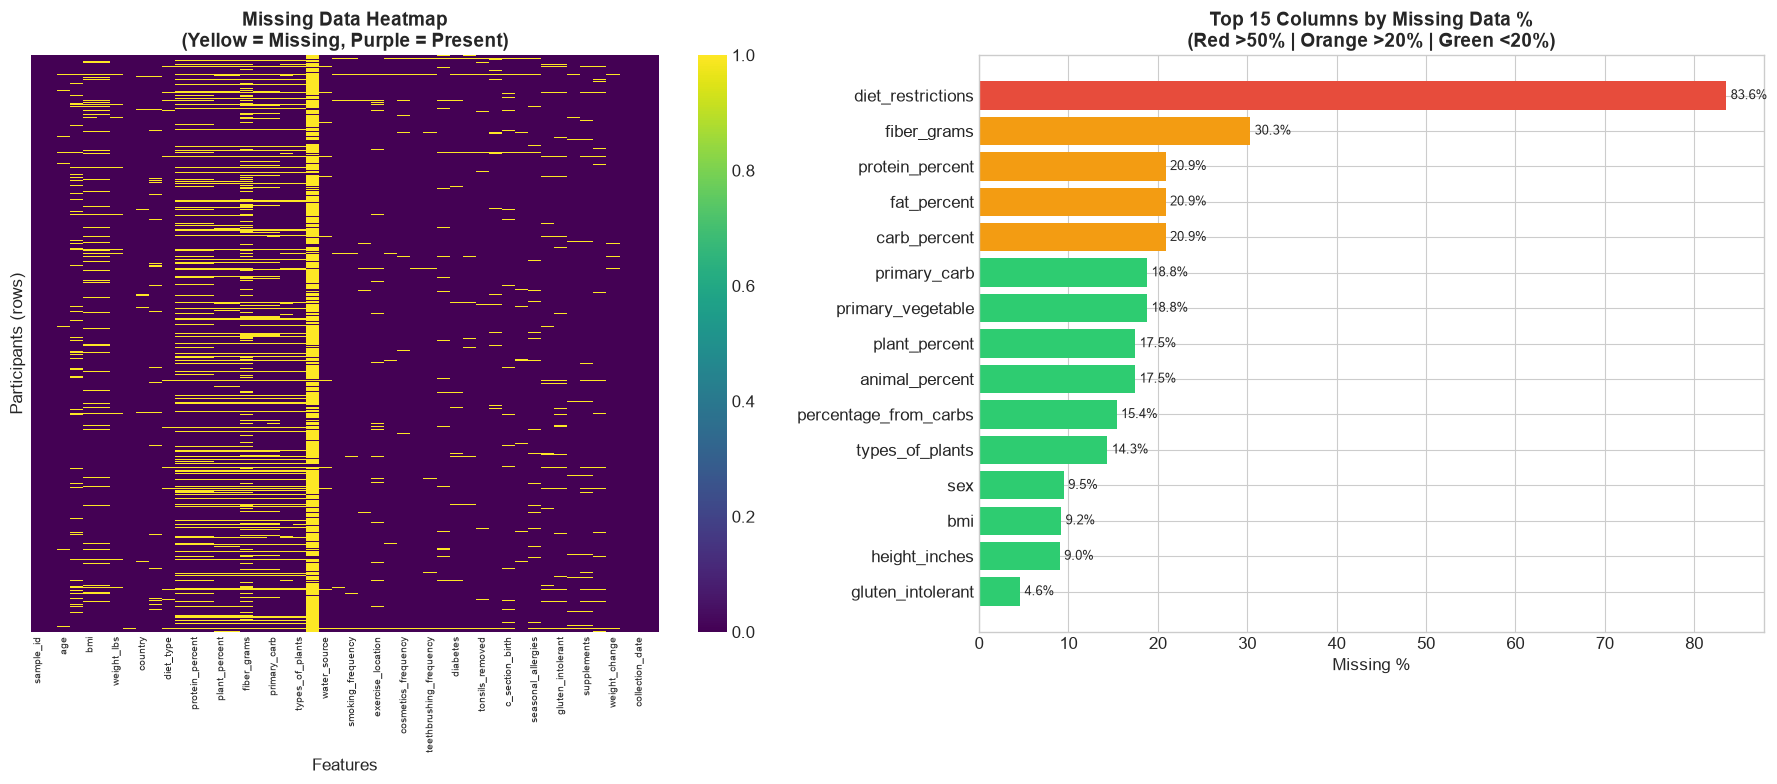


--- Interpretation ---
Columns with >50% missing should be DROPPED (unreliable for analysis).
Columns with <20% missing can be IMPUTED (filled with median/mode).
The pattern of missingness tells us which survey sections were often skipped.


In [7]:
# ============================================================
# CELL 7: Missing Value Heatmap
# ============================================================

# WHY a heatmap? It reveals PATTERNS in missing data.
# If the same rows are missing multiple columns, it means those participants
# skipped an entire section of the survey -> systematic missingness.
# Yellow = missing, Purple = present.

fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# Left: Heatmap of missing values
sns.heatmap(df.isnull(), cbar=True, yticklabels=False, cmap='viridis', ax=axes[0])
axes[0].set_title('Missing Data Heatmap\n(Yellow = Missing, Purple = Present)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Features')
axes[0].set_ylabel('Participants (rows)')
axes[0].tick_params(axis='x', rotation=90, labelsize=7)

# Right: Bar chart of missing percentages
cols_with_missing = missing[missing['Missing Count'] > 0].head(15)
colors = ['#e74c3c' if x > 50 else '#f39c12' if x > 20 else '#2ecc71' 
          for x in cols_with_missing['Missing %']]
bars = axes[1].barh(cols_with_missing.index, cols_with_missing['Missing %'], color=colors)
axes[1].set_xlabel('Missing %')
axes[1].set_title('Top 15 Columns by Missing Data %\n(Red >50% | Orange >20% | Green <20%)', 
                   fontsize=14, fontweight='bold')
axes[1].invert_yaxis()

# Add percentage labels on bars
for bar, val in zip(bars, cols_with_missing['Missing %']):
    axes[1].text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2, 
                f'{val:.1f}%', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('plots/01_missing_values.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n--- Interpretation ---')
print('Columns with >50% missing should be DROPPED (unreliable for analysis).')
print('Columns with <20% missing can be IMPUTED (filled with median/mode).')
print('The pattern of missingness tells us which survey sections were often skipped.')

---

## 3. Univariate Analysis — Understanding Individual Features

**Why univariate analysis first?**
- Before looking at relationships between variables, we need to understand each variable **individually**
- This helps us identify:
  - **Skewed distributions** → may need log transformation for ML
  - **Outliers** → can distort model training
  - **Class imbalance** → if 95% of participants don't have IBD, a model predicting "no IBD" always would be 95% accurate but useless
  - **Data quality issues** → impossible values, unexpected categories

### 3.1 Demographic Distributions

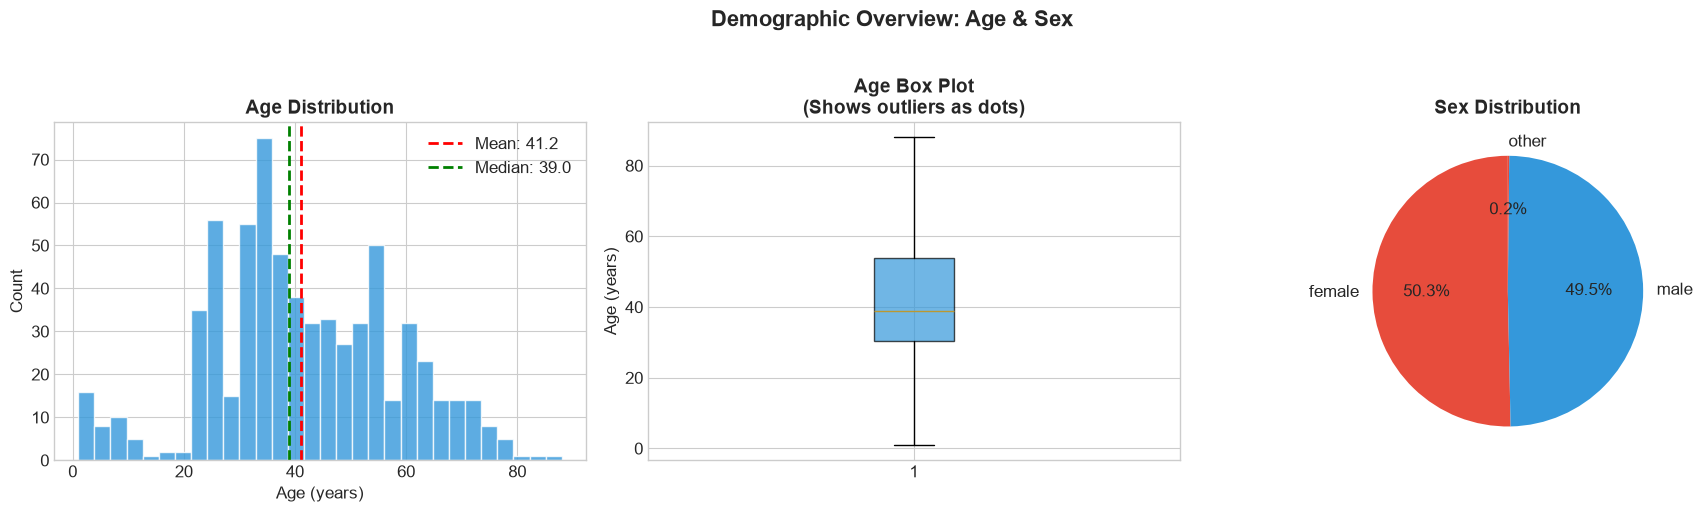


--- Key Facts ---
Age range: 1 to 88 years
Average age: 41.2 years (typical for health-conscious survey participants)
Sex ratio: {'female': 308, 'male': 303, 'other': 1}

INSIGHT: If the dataset skews toward a specific age/sex group, our findings
may not generalize to the broader population. This is a known limitation of
citizen science projects — participants tend to be health-conscious adults.


In [8]:
# ============================================================
# CELL 8: Age Distribution
# ============================================================

# WHY age matters for gut-heart research:
# - Gut microbiome diversity DECREASES with age (O'Toole & Jeffery, Nature, 2015)
# - Cardiovascular disease risk INCREASES with age
# - Understanding our age distribution tells us if our findings are generalizable
#   or biased toward a specific age group

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Histogram
axes[0].hist(df['age'].dropna(), bins=30, color='#3498db', edgecolor='white', alpha=0.8)
axes[0].axvline(df['age'].mean(), color='red', linestyle='--', linewidth=2, label=f'Mean: {df["age"].mean():.1f}')
axes[0].axvline(df['age'].median(), color='green', linestyle='--', linewidth=2, label=f'Median: {df["age"].median():.1f}')
axes[0].set_xlabel('Age (years)')
axes[0].set_ylabel('Count')
axes[0].set_title('Age Distribution', fontweight='bold')
axes[0].legend()

# Box plot
axes[1].boxplot(df['age'].dropna(), vert=True, patch_artist=True,
                boxprops=dict(facecolor='#3498db', alpha=0.7))
axes[1].set_ylabel('Age (years)')
axes[1].set_title('Age Box Plot\n(Shows outliers as dots)', fontweight='bold')

# Sex distribution
sex_counts = df['sex'].value_counts()
colors_sex = ['#e74c3c', '#3498db']
axes[2].pie(sex_counts, labels=sex_counts.index, autopct='%1.1f%%', 
            colors=colors_sex, startangle=90, textprops={'fontsize': 12})
axes[2].set_title('Sex Distribution', fontweight='bold')

plt.suptitle('Demographic Overview: Age & Sex', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('plots/02_age_sex_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n--- Key Facts ---')
print(f'Age range: {df["age"].min():.0f} to {df["age"].max():.0f} years')
print(f'Average age: {df["age"].mean():.1f} years (typical for health-conscious survey participants)')
print(f'Sex ratio: {sex_counts.to_dict()}')
print('\nINSIGHT: If the dataset skews toward a specific age/sex group, our findings')
print('may not generalize to the broader population. This is a known limitation of')
print('citizen science projects — participants tend to be health-conscious adults.')

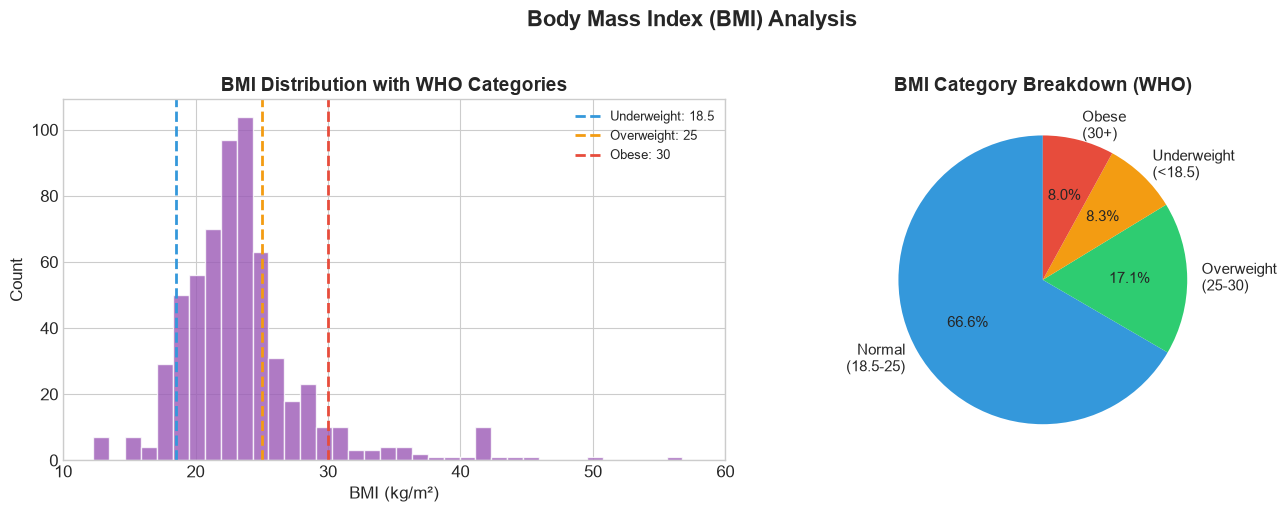


--- Key Facts ---
Average BMI: 23.6 kg/m²
Median BMI: 23.0 kg/m²

BMI Category Distribution:
  Normal (18.5-25): 409 (66.6%)
  Overweight (25-30): 105 (17.1%)
  Underweight (<18.5): 51 (8.3%)
  Obese (30+): 49 (8.0%)

FACT: A higher BMI is linked to increased TMAO production in the gut,
which promotes atherosclerosis (plaque buildup in arteries). This is a
key mechanism in the gut-heart connection (Wang et al., Nature, 2011).


In [9]:
# ============================================================
# CELL 9: BMI Distribution & Health Categories
# ============================================================

# WHY BMI is critical for gut-heart analysis:
# - BMI is one of the strongest predictors of cardiovascular disease
# - Studies show gut microbiome composition differs significantly between
#   normal-weight and obese individuals (Ley et al., Nature, 2006)
# - Obese individuals have lower Bacteroidetes/Firmicutes ratio
#
# BMI Categories (WHO standard):
#   Underweight: <18.5 | Normal: 18.5-24.9 | Overweight: 25-29.9 | Obese: 30+

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# BMI histogram
bmi_data = df['bmi'].dropna()
axes[0].hist(bmi_data, bins=40, color='#9b59b6', edgecolor='white', alpha=0.8)

# Add WHO category lines
for val, label, color in [(18.5, 'Underweight', '#3498db'), 
                           (25, 'Overweight', '#f39c12'), 
                           (30, 'Obese', '#e74c3c')]:
    axes[0].axvline(val, color=color, linestyle='--', linewidth=2, label=f'{label}: {val}')

axes[0].set_xlabel('BMI (kg/m\u00b2)')
axes[0].set_ylabel('Count')
axes[0].set_title('BMI Distribution with WHO Categories', fontweight='bold')
axes[0].legend(fontsize=9)
axes[0].set_xlim(10, 60)

# BMI category pie chart
bmi_cats = pd.cut(bmi_data, bins=[0, 18.5, 25, 30, 100], 
                  labels=['Underweight\n(<18.5)', 'Normal\n(18.5-25)', 
                          'Overweight\n(25-30)', 'Obese\n(30+)'])
cat_counts = bmi_cats.value_counts()
colors_bmi = ['#3498db', '#2ecc71', '#f39c12', '#e74c3c']
axes[1].pie(cat_counts, labels=cat_counts.index, autopct='%1.1f%%',
            colors=colors_bmi, startangle=90, textprops={'fontsize': 11})
axes[1].set_title('BMI Category Breakdown (WHO)', fontweight='bold')

plt.suptitle('Body Mass Index (BMI) Analysis', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('plots/03_bmi_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n--- Key Facts ---')
print(f'Average BMI: {bmi_data.mean():.1f} kg/m\u00b2')
print(f'Median BMI: {bmi_data.median():.1f} kg/m\u00b2')
print(f'\nBMI Category Distribution:')
for cat, count in cat_counts.items():
    print(f'  {cat.replace(chr(10), " ")}: {count} ({count/len(bmi_data)*100:.1f}%)')
print('\nFACT: A higher BMI is linked to increased TMAO production in the gut,')
print('which promotes atherosclerosis (plaque buildup in arteries). This is a')
print('key mechanism in the gut-heart connection (Wang et al., Nature, 2011).')

### 3.2 Diet Distributions

**Why diet is the centerpiece of this analysis:**
- Diet is the **primary driver** of gut microbiome composition (David et al., Nature, 2014)
- A plant-based diet promotes *Prevotella* (associated with lower heart disease risk)
- A high-fat, high-animal-protein diet promotes *Bacteroides* (associated with higher TMAO production)
- Fiber intake is perhaps the single most important dietary factor for gut health — it feeds beneficial bacteria that produce **short-chain fatty acids (SCFAs)**, which reduce inflammation and protect the heart

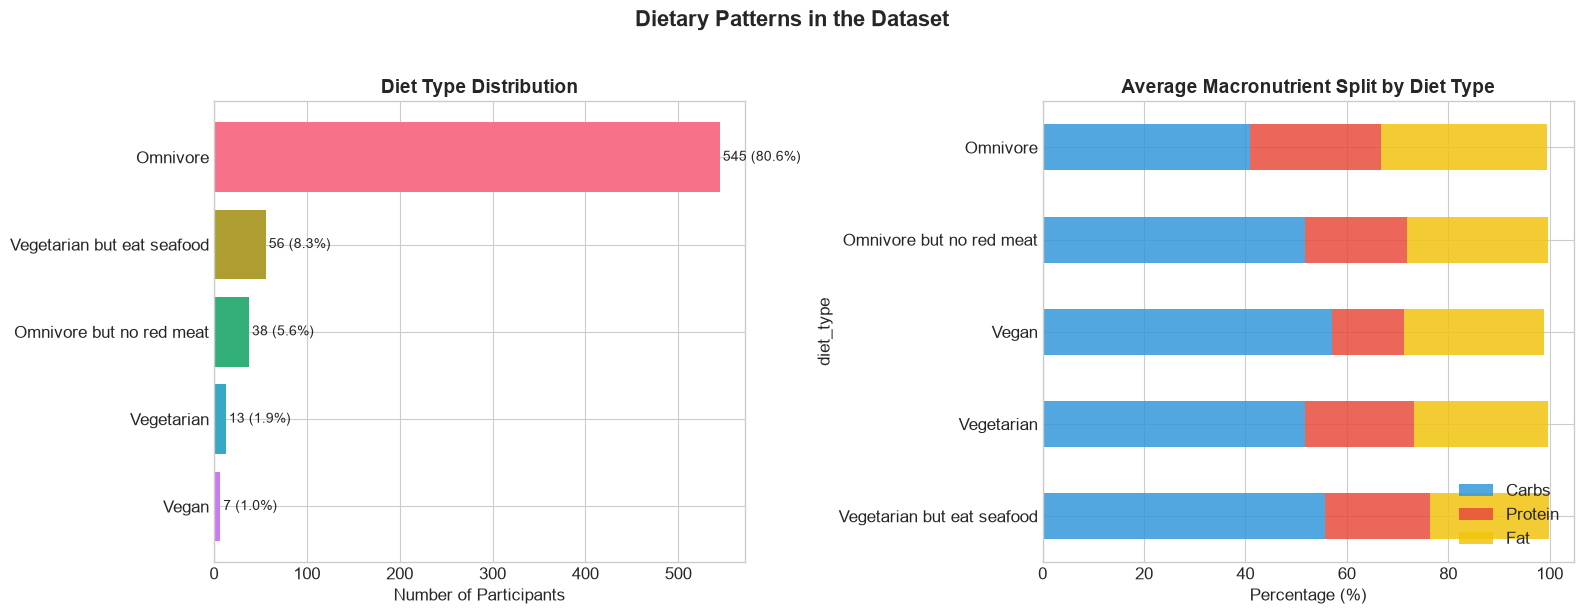


--- Key Facts ---
FACT: The American Heart Association recommends 45-65% carbs, 10-35% protein,
and 20-35% fat. Compare this to what our participants actually eat.

FACT: Vegans and vegetarians tend to have higher Prevotella (beneficial for heart)
while omnivores have higher Bacteroides (linked to TMAO and heart disease risk).


In [10]:
# ============================================================
# CELL 10: Diet Type Distribution
# ============================================================

# WHY: Diet type is the most fundamental dietary variable.
# Research shows vegetarians/vegans have distinctly different gut microbiomes
# compared to omnivores, with higher microbial diversity and more anti-inflammatory
# species (De Filippis et al., Gut, 2016).

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Diet type bar chart
diet_counts = df['diet_type'].value_counts()
colors_diet = sns.color_palette('husl', len(diet_counts))
bars = axes[0].barh(diet_counts.index, diet_counts.values, color=colors_diet)
axes[0].set_xlabel('Number of Participants')
axes[0].set_title('Diet Type Distribution', fontweight='bold')
axes[0].invert_yaxis()
# Add count labels
for bar, val in zip(bars, diet_counts.values):
    axes[0].text(bar.get_width() + 3, bar.get_y() + bar.get_height()/2,
                f'{val} ({val/len(df)*100:.1f}%)', va='center', fontsize=10)

# Macronutrient composition by diet type
macro_cols = ['carb_percent', 'protein_percent', 'fat_percent']
macro_by_diet = df.groupby('diet_type')[macro_cols].mean().dropna()
macro_by_diet.plot(kind='barh', stacked=True, ax=axes[1], 
                   color=['#3498db', '#e74c3c', '#f1c40f'], alpha=0.85)
axes[1].set_xlabel('Percentage (%)')
axes[1].set_title('Average Macronutrient Split by Diet Type', fontweight='bold')
axes[1].legend(['Carbs', 'Protein', 'Fat'], loc='lower right')
axes[1].invert_yaxis()

plt.suptitle('Dietary Patterns in the Dataset', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('plots/04_diet_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n--- Key Facts ---')
print('FACT: The American Heart Association recommends 45-65% carbs, 10-35% protein,')
print('and 20-35% fat. Compare this to what our participants actually eat.')
print('\nFACT: Vegans and vegetarians tend to have higher Prevotella (beneficial for heart)')
print('while omnivores have higher Bacteroides (linked to TMAO and heart disease risk).')

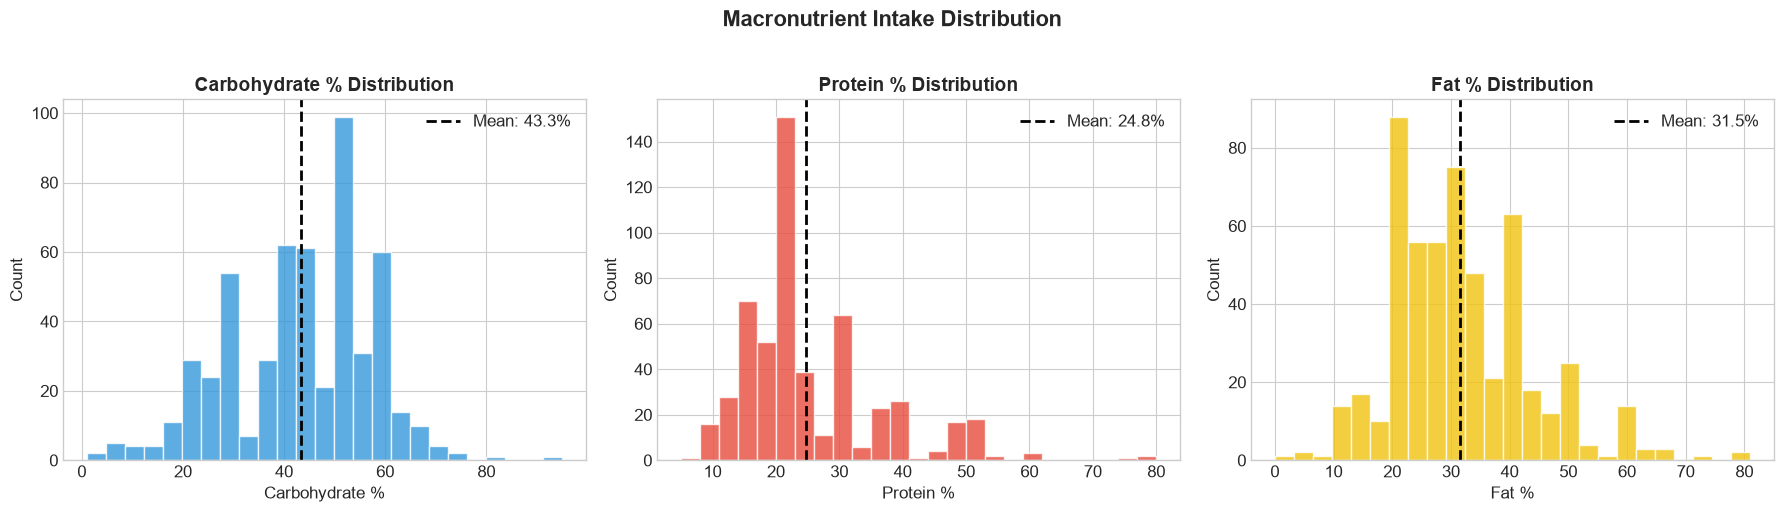


--- Key Facts ---
Carbohydrate %: Mean=43.3%, Median=45.0%, Std=14.2%
Protein %: Mean=24.8%, Median=20.0%, Std=11.2%
Fat %: Mean=31.5%, Median=30.0%, Std=12.1%


In [11]:
# ============================================================
# CELL 11: Macronutrient Distribution (Carbs, Protein, Fat)
# ============================================================

# WHY: The balance of macronutrients directly shapes gut microbiome composition.
# - High carb (especially fiber) -> feeds Bifidobacteria & Lactobacillus (good!)
# - High protein -> increases protein fermentation byproducts (hydrogen sulfide, harmful)
# - High fat -> increases bile acid production, shifts gut bacteria toward inflammation

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
macro_data = [('carb_percent', 'Carbohydrate %', '#3498db'),
              ('protein_percent', 'Protein %', '#e74c3c'),
              ('fat_percent', 'Fat %', '#f1c40f')]

for i, (col, title, color) in enumerate(macro_data):
    data = df[col].dropna()
    axes[i].hist(data, bins=25, color=color, edgecolor='white', alpha=0.8)
    axes[i].axvline(data.mean(), color='black', linestyle='--', linewidth=2,
                    label=f'Mean: {data.mean():.1f}%')
    axes[i].set_xlabel(title)
    axes[i].set_ylabel('Count')
    axes[i].set_title(f'{title} Distribution', fontweight='bold')
    axes[i].legend()

plt.suptitle('Macronutrient Intake Distribution', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('plots/05_macronutrient_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n--- Key Facts ---')
for col, name, _ in macro_data:
    d = df[col].dropna()
    print(f'{name}: Mean={d.mean():.1f}%, Median={d.median():.1f}%, Std={d.std():.1f}%')

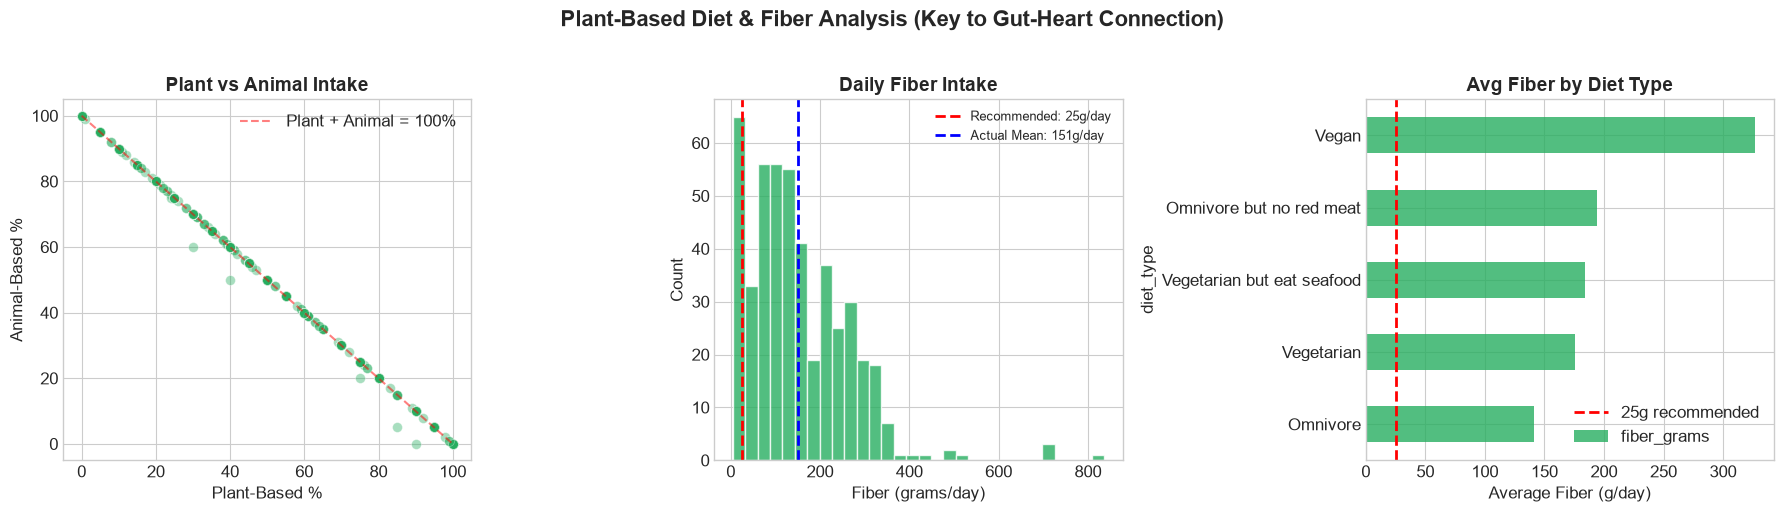


--- Key Facts ---
Average fiber intake: 151g/day
Participants meeting 25g/day recommendation: 432 (91.7%)

FACT: Only ~5% of Americans meet the recommended 25g fiber/day (USDA).
FACT: Each 7g/day increase in fiber reduces heart disease risk by 9% (BMJ meta-analysis).
FACT: Fiber feeds Faecalibacterium prausnitzii, a key anti-inflammatory gut bacterium.


In [12]:
# ============================================================
# CELL 12: Plant vs Animal Intake & Fiber
# ============================================================

# WHY this is the MOST IMPORTANT dietary plot for gut-heart research:
# - Plant-based diets are associated with 25% lower risk of heart disease (BMJ, 2019)
# - Fiber is fermented by gut bacteria into SCFAs (butyrate, propionate, acetate)
# - SCFAs reduce intestinal inflammation, strengthen gut barrier, lower blood pressure
# - The gut-heart axis theory: Diet -> Gut bacteria -> Metabolites -> Heart health

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Plant vs Animal scatter
axes[0].scatter(df['plant_percent'], df['animal_percent'], alpha=0.4, 
                c='#27ae60', edgecolors='white', linewidth=0.5, s=50)
axes[0].set_xlabel('Plant-Based %')
axes[0].set_ylabel('Animal-Based %')
axes[0].set_title('Plant vs Animal Intake', fontweight='bold')
# Add reference line (plant + animal should = 100%)
axes[0].plot([0, 100], [100, 0], 'r--', alpha=0.5, label='Plant + Animal = 100%')
axes[0].legend()

# Fiber distribution
fiber_data = df['fiber_grams'].dropna()
axes[1].hist(fiber_data, bins=30, color='#27ae60', edgecolor='white', alpha=0.8)
axes[1].axvline(25, color='red', linestyle='--', linewidth=2, label='Recommended: 25g/day')
axes[1].axvline(fiber_data.mean(), color='blue', linestyle='--', linewidth=2, 
                label=f'Actual Mean: {fiber_data.mean():.0f}g/day')
axes[1].set_xlabel('Fiber (grams/day)')
axes[1].set_ylabel('Count')
axes[1].set_title('Daily Fiber Intake', fontweight='bold')
axes[1].legend(fontsize=9)

# Fiber by diet type
fiber_by_diet = df.groupby('diet_type')['fiber_grams'].mean().sort_values(ascending=True)
fiber_by_diet.plot(kind='barh', ax=axes[2], color='#27ae60', alpha=0.8)
axes[2].axvline(25, color='red', linestyle='--', linewidth=2, label='25g recommended')
axes[2].set_xlabel('Average Fiber (g/day)')
axes[2].set_title('Avg Fiber by Diet Type', fontweight='bold')
axes[2].legend()

plt.suptitle('Plant-Based Diet & Fiber Analysis (Key to Gut-Heart Connection)', 
             fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('plots/06_plant_fiber_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

above_rec = (fiber_data >= 25).sum()
print(f'\n--- Key Facts ---')
print(f'Average fiber intake: {fiber_data.mean():.0f}g/day')
print(f'Participants meeting 25g/day recommendation: {above_rec} ({above_rec/len(fiber_data)*100:.1f}%)')
print(f'\nFACT: Only ~5% of Americans meet the recommended 25g fiber/day (USDA).')
print(f'FACT: Each 7g/day increase in fiber reduces heart disease risk by 9% (BMJ meta-analysis).')
print(f'FACT: Fiber feeds Faecalibacterium prausnitzii, a key anti-inflammatory gut bacterium.')

### 3.3 Health Condition Distributions

**Why we care about these specific conditions:**
- **IBD (Inflammatory Bowel Disease)** — A direct gut condition; strongly linked to microbiome dysbiosis. Patients with IBD have significantly reduced microbial diversity.
- **Diabetes** — Type 2 diabetes is both a cardiovascular risk factor AND associated with altered gut microbiome. Gut bacteria influence insulin sensitivity.
- **Seasonal allergies** — Reflect immune system function, which is modulated by the gut (70% of immune cells are in the gut!).
- **Antibiotic history** — Antibiotics destroy gut bacteria indiscriminately. Recovery can take 6-12 months. This is a major confounding variable.

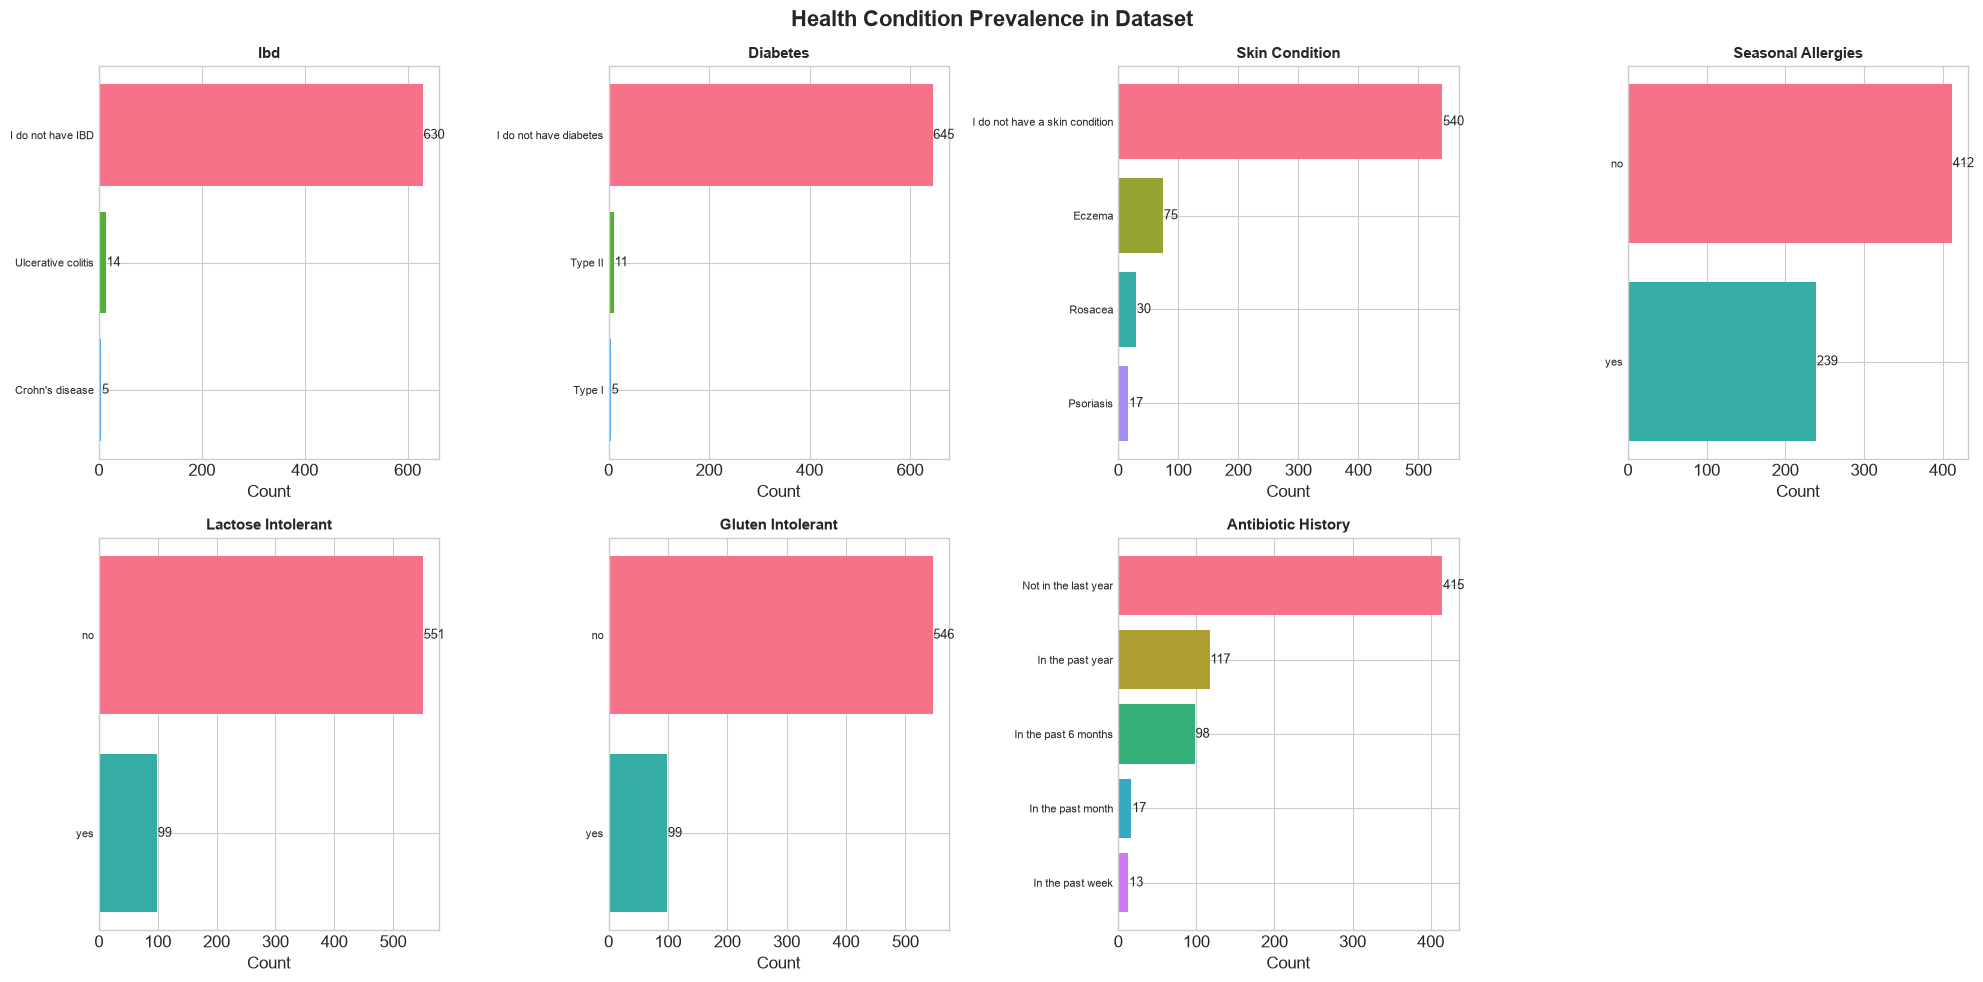


--- Key Facts ---
FACT: IBD affects ~1.6 million Americans. If our dataset reflects this,
we expect ~2-3% prevalence. Significantly higher = sampling bias.

FACT: 70% of the immune system resides in the gut (GALT - Gut-Associated
Lymphoid Tissue). This explains why gut health affects allergies, skin, and more.


In [13]:
# ============================================================
# CELL 13: Health Conditions Overview
# ============================================================

# WHY: Understanding the prevalence of health conditions tells us:
# 1. If we have enough samples per condition to build reliable models
# 2. If there's class imbalance (very common in health data)
# 3. Which conditions are worth modeling vs. too rare to analyze

health_cols = ['ibd', 'diabetes', 'skin_condition', 'seasonal_allergies', 
               'lactose_intolerant', 'gluten_intolerant', 'antibiotic_history']

fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, col in enumerate(health_cols):
    counts = df[col].value_counts().head(6)  # Top 6 categories
    colors_h = sns.color_palette('husl', len(counts))
    bars = axes[i].barh(range(len(counts)), counts.values, color=colors_h)
    axes[i].set_yticks(range(len(counts)))
    axes[i].set_yticklabels([str(x)[:35] for x in counts.index], fontsize=8)
    axes[i].set_xlabel('Count')
    axes[i].set_title(col.replace('_', ' ').title(), fontweight='bold', fontsize=11)
    axes[i].invert_yaxis()
    
    # Add count labels
    for bar, val in zip(bars, counts.values):
        axes[i].text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
                    str(val), va='center', fontsize=9)

# Hide last subplot if odd number
axes[-1].axis('off')

plt.suptitle('Health Condition Prevalence in Dataset', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/07_health_conditions.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n--- Key Facts ---')
print('FACT: IBD affects ~1.6 million Americans. If our dataset reflects this,')
print('we expect ~2-3% prevalence. Significantly higher = sampling bias.')
print('\nFACT: 70% of the immune system resides in the gut (GALT - Gut-Associated')
print('Lymphoid Tissue). This explains why gut health affects allergies, skin, and more.')

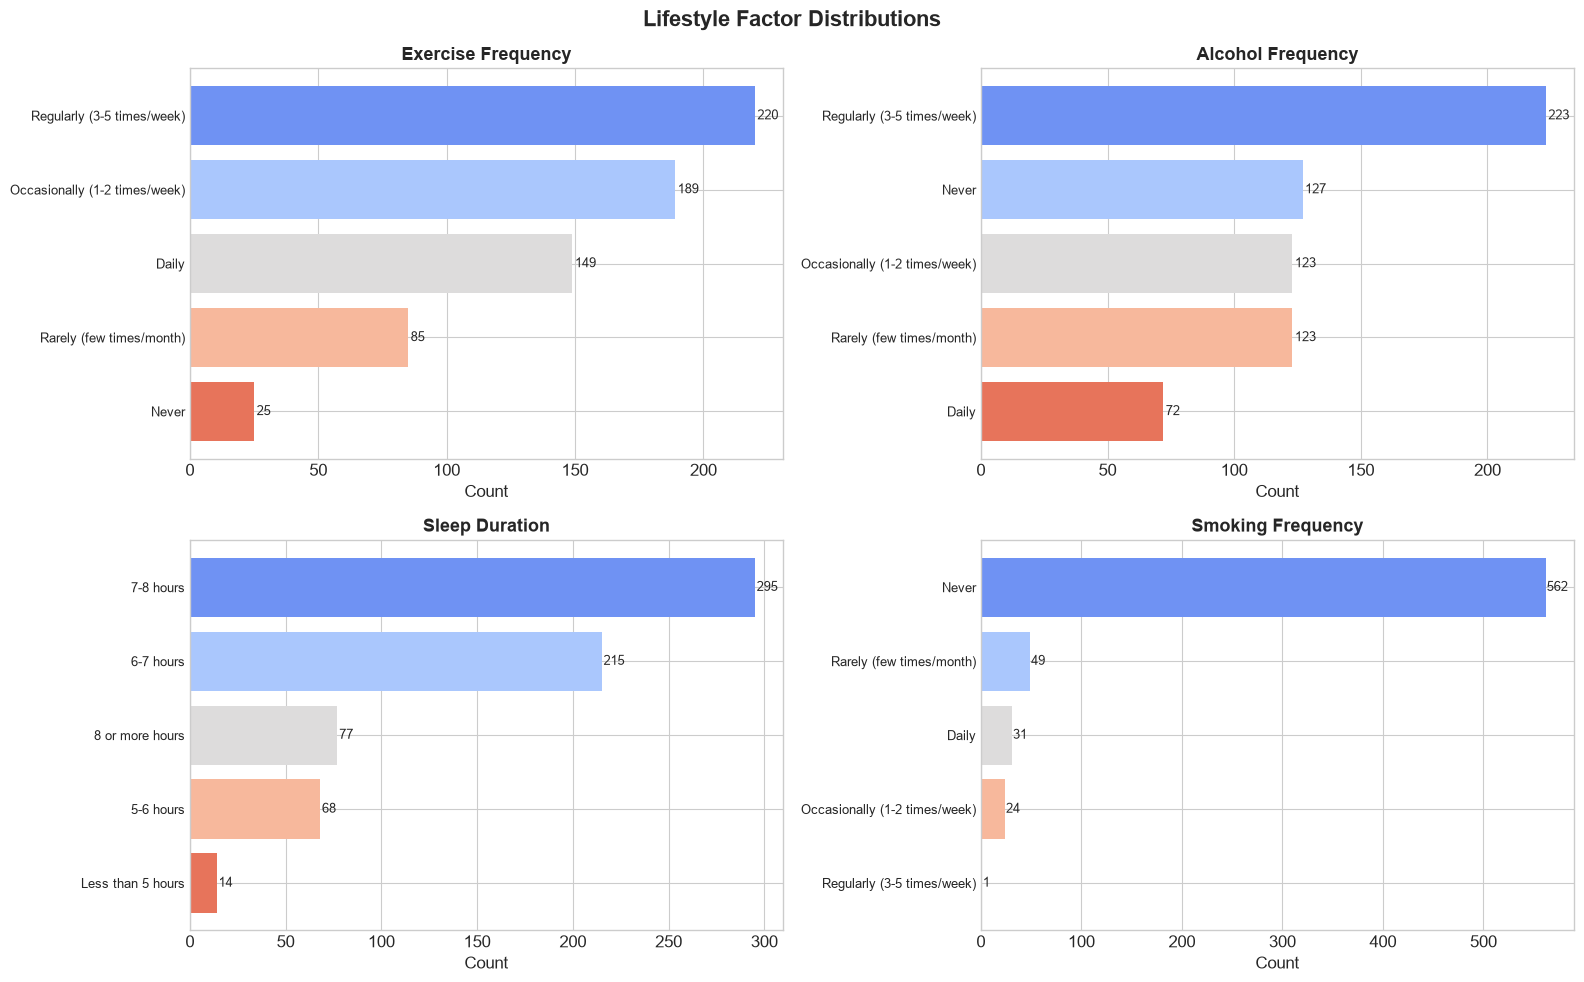


--- Key Facts ---
FACT: Regular exercise is one of the FEW interventions proven to increase
gut microbial diversity independent of diet (Allen et al., Medicine & Science, 2018).

FACT: Moderate alcohol may increase Lactobacillus, but heavy drinking causes
gut barrier dysfunction ("leaky gut") and endotoxemia — a direct path to heart disease.

FACT: <6 hours of sleep alters Firmicutes/Bacteroidetes ratio within 2 days,
mimicking the gut profile of obese individuals (Benedict et al., 2016).


In [14]:
# ============================================================
# CELL 14: Lifestyle Factors
# ============================================================

# WHY lifestyle factors matter for gut-heart:
# - Exercise increases gut microbial diversity by 30% (Clarke et al., Gut, 2014)
# - Alcohol disrupts gut barrier ("leaky gut") leading to systemic inflammation
# - Sleep deprivation alters gut microbiome within 48 hours (Benedict et al., 2016)
# - Smoking changes bile acid metabolism and promotes harmful gut bacteria

lifestyle_cols = ['exercise_frequency', 'alcohol_frequency', 
                  'sleep_duration', 'smoking_frequency']

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
axes = axes.flatten()

for i, col in enumerate(lifestyle_cols):
    counts = df[col].value_counts()
    colors_l = sns.color_palette('coolwarm', len(counts))
    bars = axes[i].barh(range(len(counts)), counts.values, color=colors_l)
    axes[i].set_yticks(range(len(counts)))
    axes[i].set_yticklabels([str(x)[:40] for x in counts.index], fontsize=9)
    axes[i].set_xlabel('Count')
    axes[i].set_title(col.replace('_', ' ').title(), fontweight='bold', fontsize=13)
    axes[i].invert_yaxis()
    
    for bar, val in zip(bars, counts.values):
        axes[i].text(bar.get_width() + 1, bar.get_y() + bar.get_height()/2,
                    f'{val}', va='center', fontsize=9)

plt.suptitle('Lifestyle Factor Distributions', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/08_lifestyle_factors.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n--- Key Facts ---')
print('FACT: Regular exercise is one of the FEW interventions proven to increase')
print('gut microbial diversity independent of diet (Allen et al., Medicine & Science, 2018).')
print('\nFACT: Moderate alcohol may increase Lactobacillus, but heavy drinking causes')
print('gut barrier dysfunction ("leaky gut") and endotoxemia — a direct path to heart disease.')
print('\nFACT: <6 hours of sleep alters Firmicutes/Bacteroidetes ratio within 2 days,')
print('mimicking the gut profile of obese individuals (Benedict et al., 2016).')

---

## 4. Bivariate Analysis — Relationships Between Variables

**Why bivariate analysis?**
- Now that we understand each variable individually, we explore how they **relate to each other**
- This is where we test hypotheses like:
  - *Do vegetarians have lower BMI?*
  - *Does exercise frequency correlate with better gut health (no IBD)?*
  - *Is higher fiber intake associated with fewer health conditions?*
- These insights directly inform which features to include in our ML models

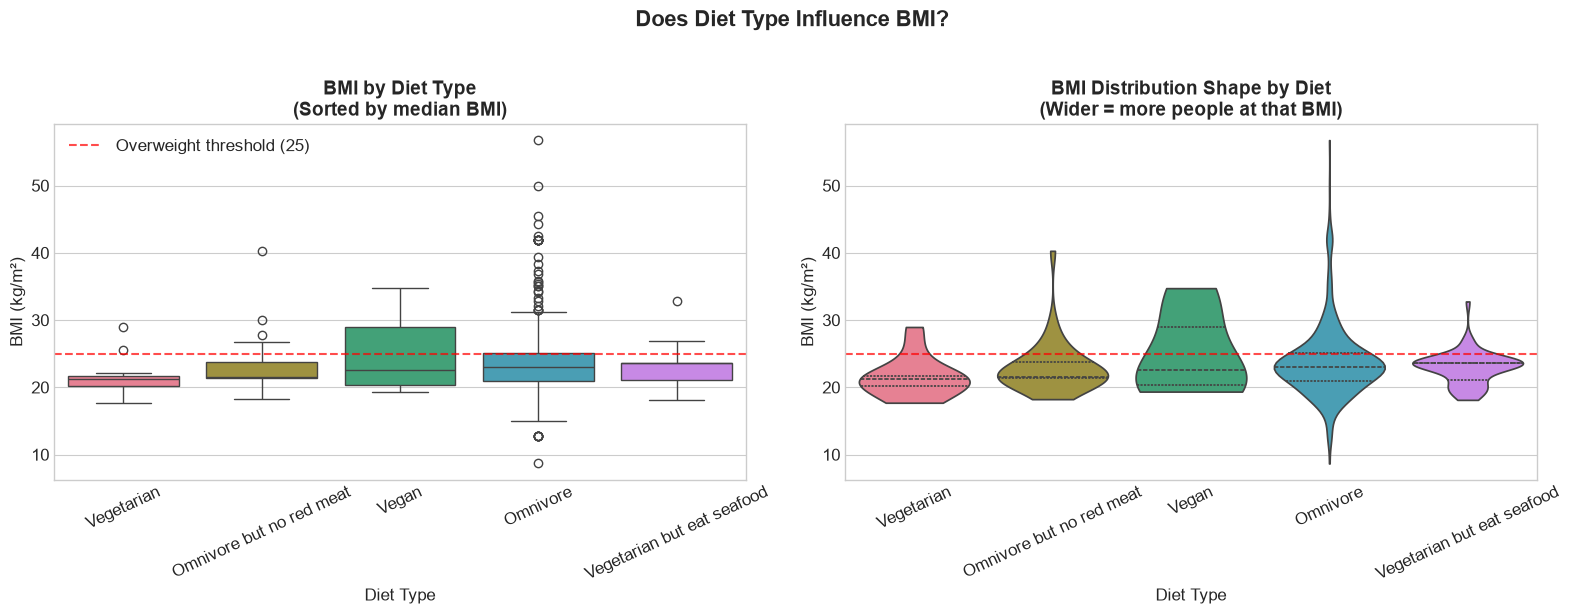


--- Average BMI by Diet Type ---
                            mean  median  count
diet_type                                      
Vegetarian                 21.53   21.19     12
Omnivore but no red meat   22.93   21.54     36
Vegan                      24.98   22.55      6
Omnivore                   23.81   23.02    494
Vegetarian but eat seafood 22.91   23.67     51

INSIGHT: If vegans/vegetarians show lower median BMI, this supports the
hypothesis that plant-based diets -> healthier gut bacteria -> lower body weight.
This is the "microbiome-mediated weight regulation" theory.


In [15]:
# ============================================================
# CELL 15: BMI by Diet Type
# ============================================================

# HYPOTHESIS: Vegetarians/Vegans have lower BMI than omnivores.
# WHY: Plant-based diets are associated with lower caloric density,
# higher fiber (increased satiety), and different gut bacteria that
# extract fewer calories from food (Turnbaugh et al., Nature, 2006).

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Box plot: BMI by Diet Type
diet_order = df.groupby('diet_type')['bmi'].median().sort_values().index
sns.boxplot(data=df, x='diet_type', y='bmi', order=diet_order, ax=axes[0],
            palette='husl', showfliers=True)
axes[0].axhline(25, color='red', linestyle='--', alpha=0.7, label='Overweight threshold (25)')
axes[0].set_xlabel('Diet Type')
axes[0].set_ylabel('BMI (kg/m\u00b2)')
axes[0].set_title('BMI by Diet Type\n(Sorted by median BMI)', fontweight='bold')
axes[0].tick_params(axis='x', rotation=25)
axes[0].legend()

# Violin plot: BMI by Diet Type (shows full distribution shape)
sns.violinplot(data=df, x='diet_type', y='bmi', order=diet_order, ax=axes[1],
               palette='husl', inner='quartile', cut=0)
axes[1].axhline(25, color='red', linestyle='--', alpha=0.7)
axes[1].set_xlabel('Diet Type')
axes[1].set_ylabel('BMI (kg/m\u00b2)')
axes[1].set_title('BMI Distribution Shape by Diet\n(Wider = more people at that BMI)', fontweight='bold')
axes[1].tick_params(axis='x', rotation=25)

plt.suptitle('Does Diet Type Influence BMI?', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('plots/09_bmi_by_diet.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n--- Average BMI by Diet Type ---')
bmi_stats = df.groupby('diet_type')['bmi'].agg(['mean', 'median', 'count']).sort_values('median')
print(bmi_stats.round(2).to_string())
print('\nINSIGHT: If vegans/vegetarians show lower median BMI, this supports the')
print('hypothesis that plant-based diets -> healthier gut bacteria -> lower body weight.')
print('This is the "microbiome-mediated weight regulation" theory.')

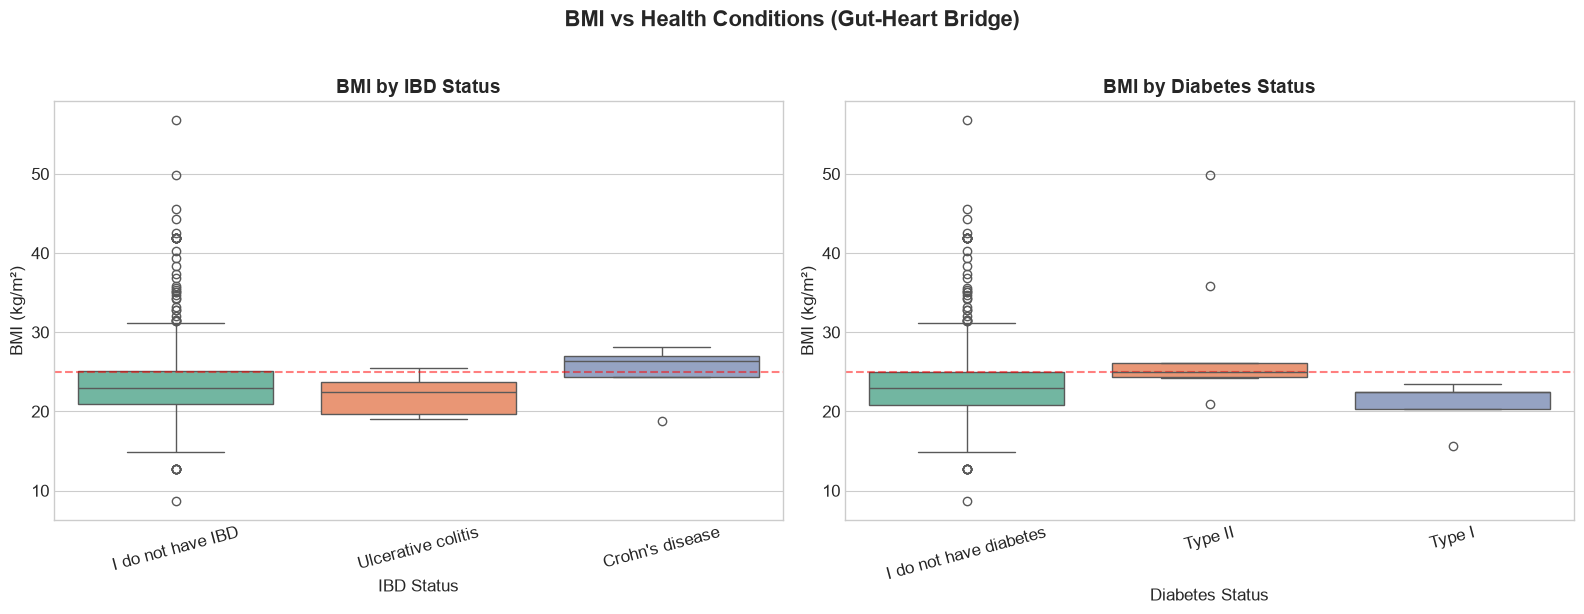


--- Key Facts ---
FACT: IBD patients often experience weight loss due to malabsorption and
chronic inflammation, which reduces nutrient uptake in the gut.

FACT: Type 2 diabetes and obesity share a common mechanism through the gut:
dysbiotic gut bacteria -> increased intestinal permeability -> lipopolysaccharide (LPS)
leakage into blood -> chronic low-grade inflammation -> insulin resistance.


In [16]:
# ============================================================
# CELL 16: BMI by Health Conditions (IBD & Diabetes)
# ============================================================

# WHY: BMI is a bridge between gut and heart.
# - IBD patients often have LOWER BMI (malabsorption)
# - Diabetes patients often have HIGHER BMI (insulin resistance)
# - These opposite trends help us understand how gut conditions vs.
#   metabolic conditions relate to body composition.

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# BMI by IBD status
sns.boxplot(data=df, x='ibd', y='bmi', ax=axes[0], palette='Set2')
axes[0].axhline(25, color='red', linestyle='--', alpha=0.5)
axes[0].set_title('BMI by IBD Status', fontweight='bold')
axes[0].set_xlabel('IBD Status')
axes[0].set_ylabel('BMI (kg/m\u00b2)')
axes[0].tick_params(axis='x', rotation=15)

# BMI by Diabetes status
sns.boxplot(data=df, x='diabetes', y='bmi', ax=axes[1], palette='Set2')
axes[1].axhline(25, color='red', linestyle='--', alpha=0.5)
axes[1].set_title('BMI by Diabetes Status', fontweight='bold')
axes[1].set_xlabel('Diabetes Status')
axes[1].set_ylabel('BMI (kg/m\u00b2)')
axes[1].tick_params(axis='x', rotation=15)

plt.suptitle('BMI vs Health Conditions (Gut-Heart Bridge)', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('plots/10_bmi_by_health.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n--- Key Facts ---')
print('FACT: IBD patients often experience weight loss due to malabsorption and')
print('chronic inflammation, which reduces nutrient uptake in the gut.')
print('\nFACT: Type 2 diabetes and obesity share a common mechanism through the gut:')
print('dysbiotic gut bacteria -> increased intestinal permeability -> lipopolysaccharide (LPS)')
print('leakage into blood -> chronic low-grade inflammation -> insulin resistance.')

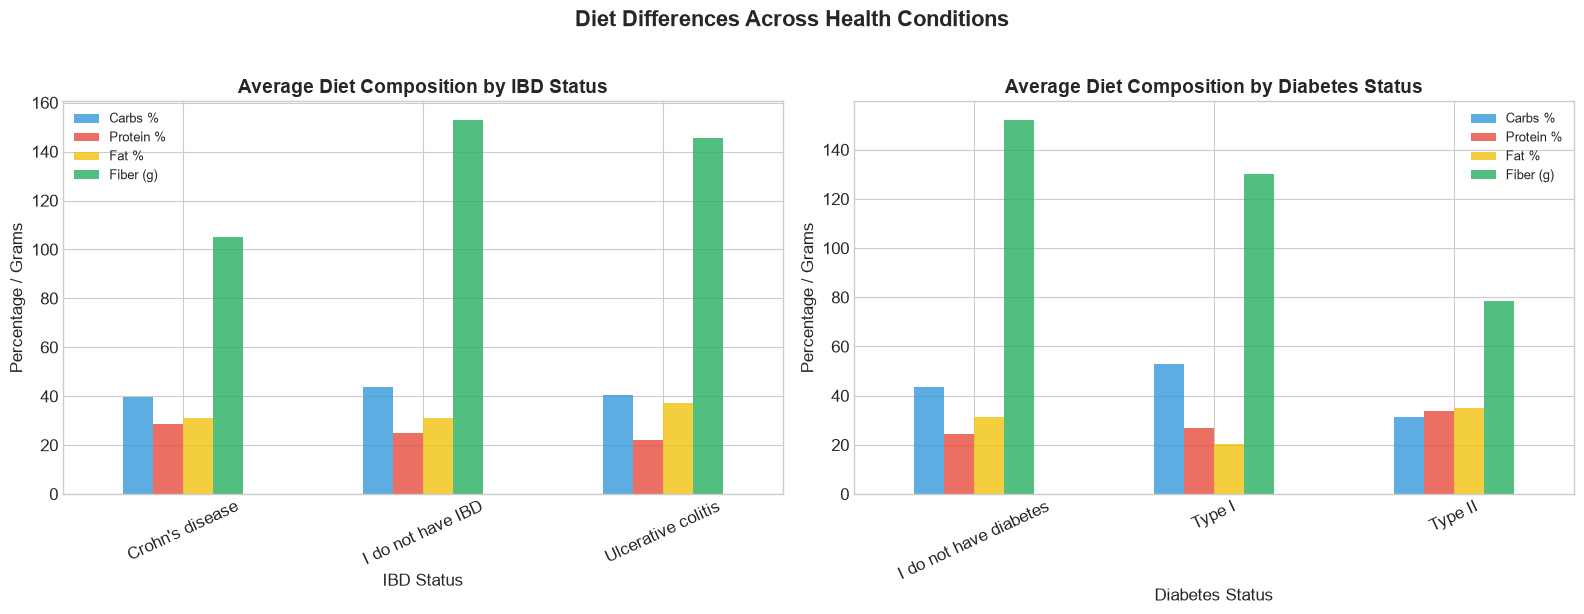


--- What to look for ---
If IBD/diabetic participants show different macronutrient patterns, it suggests
diet modification could be a therapeutic approach (and a strong ML feature).

FACT: A Mediterranean diet (high fiber, healthy fats, low processed food)
reduces cardiovascular events by 30% AND improves gut microbiome diversity
(PREDIMED trial, NEJM, 2018).


In [17]:
# ============================================================
# CELL 17: Diet Composition by Health Outcomes
# ============================================================

# WHY: This directly tests the gut-heart hypothesis.
# If people with IBD/diabetes eat differently, it suggests diet as a
# potential intervention point. This is actionable for healthcare.

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Average macronutrients by IBD status
macro_cols = ['carb_percent', 'protein_percent', 'fat_percent', 'fiber_grams']
ibd_macro = df.groupby('ibd')[macro_cols].mean()
ibd_macro.plot(kind='bar', ax=axes[0], color=['#3498db', '#e74c3c', '#f1c40f', '#27ae60'], alpha=0.8)
axes[0].set_title('Average Diet Composition by IBD Status', fontweight='bold')
axes[0].set_xlabel('IBD Status')
axes[0].set_ylabel('Percentage / Grams')
axes[0].tick_params(axis='x', rotation=25)
axes[0].legend(['Carbs %', 'Protein %', 'Fat %', 'Fiber (g)'], fontsize=9)

# Average macronutrients by Diabetes status  
diab_macro = df.groupby('diabetes')[macro_cols].mean()
diab_macro.plot(kind='bar', ax=axes[1], color=['#3498db', '#e74c3c', '#f1c40f', '#27ae60'], alpha=0.8)
axes[1].set_title('Average Diet Composition by Diabetes Status', fontweight='bold')
axes[1].set_xlabel('Diabetes Status')
axes[1].set_ylabel('Percentage / Grams')
axes[1].tick_params(axis='x', rotation=25)
axes[1].legend(['Carbs %', 'Protein %', 'Fat %', 'Fiber (g)'], fontsize=9)

plt.suptitle('Diet Differences Across Health Conditions', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('plots/11_diet_by_health.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n--- What to look for ---')
print('If IBD/diabetic participants show different macronutrient patterns, it suggests')
print('diet modification could be a therapeutic approach (and a strong ML feature).')
print('\nFACT: A Mediterranean diet (high fiber, healthy fats, low processed food)')
print('reduces cardiovascular events by 30% AND improves gut microbiome diversity')
print('(PREDIMED trial, NEJM, 2018).')

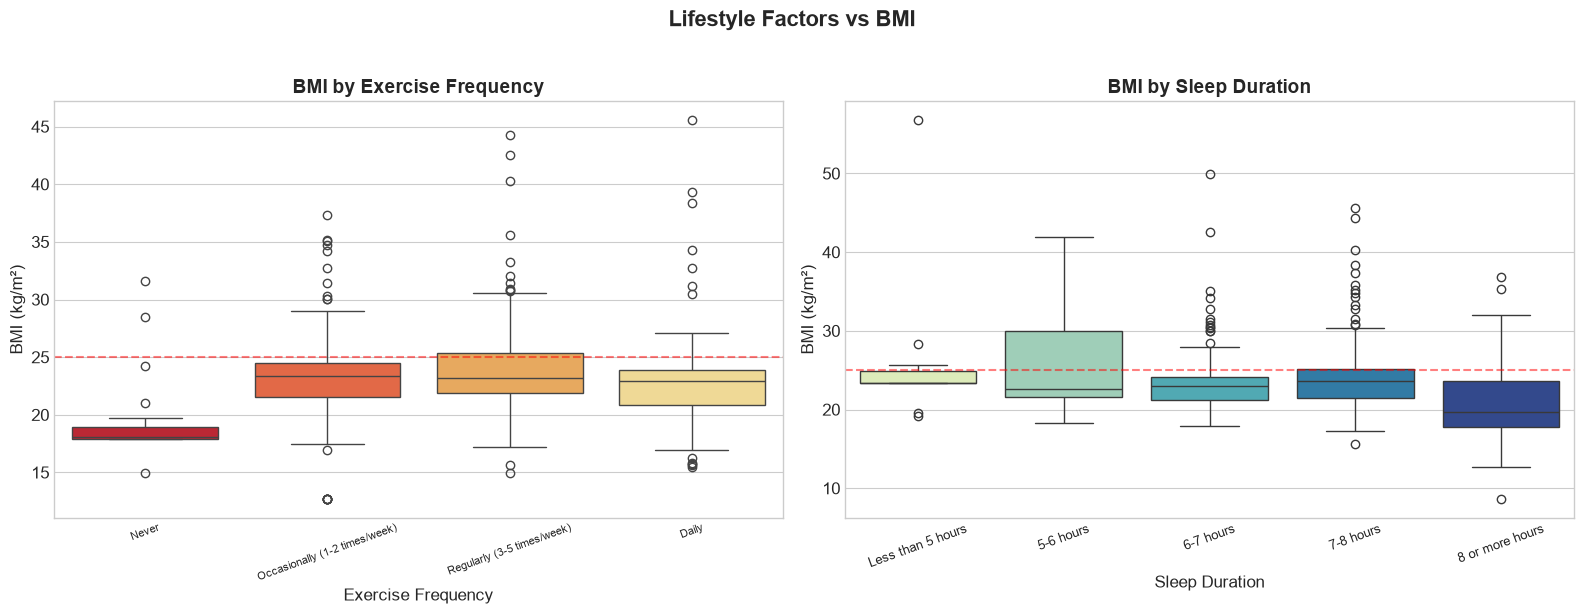


--- Key Facts ---
FACT: Exercise increases Akkermansia muciniphila abundance by up to 40%.
This bacterium strengthens the gut lining and is inversely correlated with obesity.

FACT: Sleeping <6 hours increases ghrelin (hunger hormone) and decreases
leptin (satiety hormone), leading to overeating. The gut microbiome mediates
this through the vagus nerve (gut-brain-heart axis).


In [18]:
# ============================================================
# CELL 18: Exercise & Sleep vs BMI
# ============================================================

# WHY: Exercise and sleep are the two most impactful non-dietary lifestyle
# factors for both gut and heart health.
# - Exercise: increases Akkermansia muciniphila (gut barrier strengthener)
# - Sleep: circadian rhythm disruption alters gut bacteria within 48 hours

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# BMI by Exercise frequency
exercise_order = ['Never', 'Rarely (a few times/month)', 
                  'Occasionally (1-2 times/week)', 
                  'Regularly (3-5 times/week)', 'Daily']
# Filter to known categories
ex_data = df[df['exercise_frequency'].isin(exercise_order)]
sns.boxplot(data=ex_data, x='exercise_frequency', y='bmi', 
            order=[x for x in exercise_order if x in ex_data['exercise_frequency'].values],
            ax=axes[0], palette='YlOrRd_r')
axes[0].set_title('BMI by Exercise Frequency', fontweight='bold')
axes[0].set_xlabel('Exercise Frequency')
axes[0].set_ylabel('BMI (kg/m\u00b2)')
axes[0].tick_params(axis='x', rotation=20, labelsize=8)
axes[0].axhline(25, color='red', linestyle='--', alpha=0.5)

# BMI by Sleep duration
sleep_order = ['Less than 5 hours', '5-6 hours', '6-7 hours', '7-8 hours', '8 or more hours']
sl_data = df[df['sleep_duration'].isin(sleep_order)]
sns.boxplot(data=sl_data, x='sleep_duration', y='bmi',
            order=[x for x in sleep_order if x in sl_data['sleep_duration'].values],
            ax=axes[1], palette='YlGnBu')
axes[1].set_title('BMI by Sleep Duration', fontweight='bold')
axes[1].set_xlabel('Sleep Duration')
axes[1].set_ylabel('BMI (kg/m\u00b2)')
axes[1].tick_params(axis='x', rotation=20, labelsize=9)
axes[1].axhline(25, color='red', linestyle='--', alpha=0.5)

plt.suptitle('Lifestyle Factors vs BMI', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('plots/12_lifestyle_vs_bmi.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n--- Key Facts ---')
print('FACT: Exercise increases Akkermansia muciniphila abundance by up to 40%.')
print('This bacterium strengthens the gut lining and is inversely correlated with obesity.')
print('\nFACT: Sleeping <6 hours increases ghrelin (hunger hormone) and decreases')
print('leptin (satiety hormone), leading to overeating. The gut microbiome mediates')
print('this through the vagus nerve (gut-brain-heart axis).')

---

## 5. Correlation Analysis

**Why correlation analysis is essential:**
- Correlations reveal which numerical features move together (or inversely)
- Strong correlations between features = **multicollinearity** (problematic for linear models)
- Strong correlations between features and targets = **good predictors for ML**
- Correlation ≠ causation, but it guides our hypothesis generation

**Interpreting the heatmap:**
- Values range from -1 (perfect negative) to +1 (perfect positive)
- |r| > 0.7 = strong correlation
- |r| 0.4-0.7 = moderate correlation
- |r| < 0.4 = weak correlation

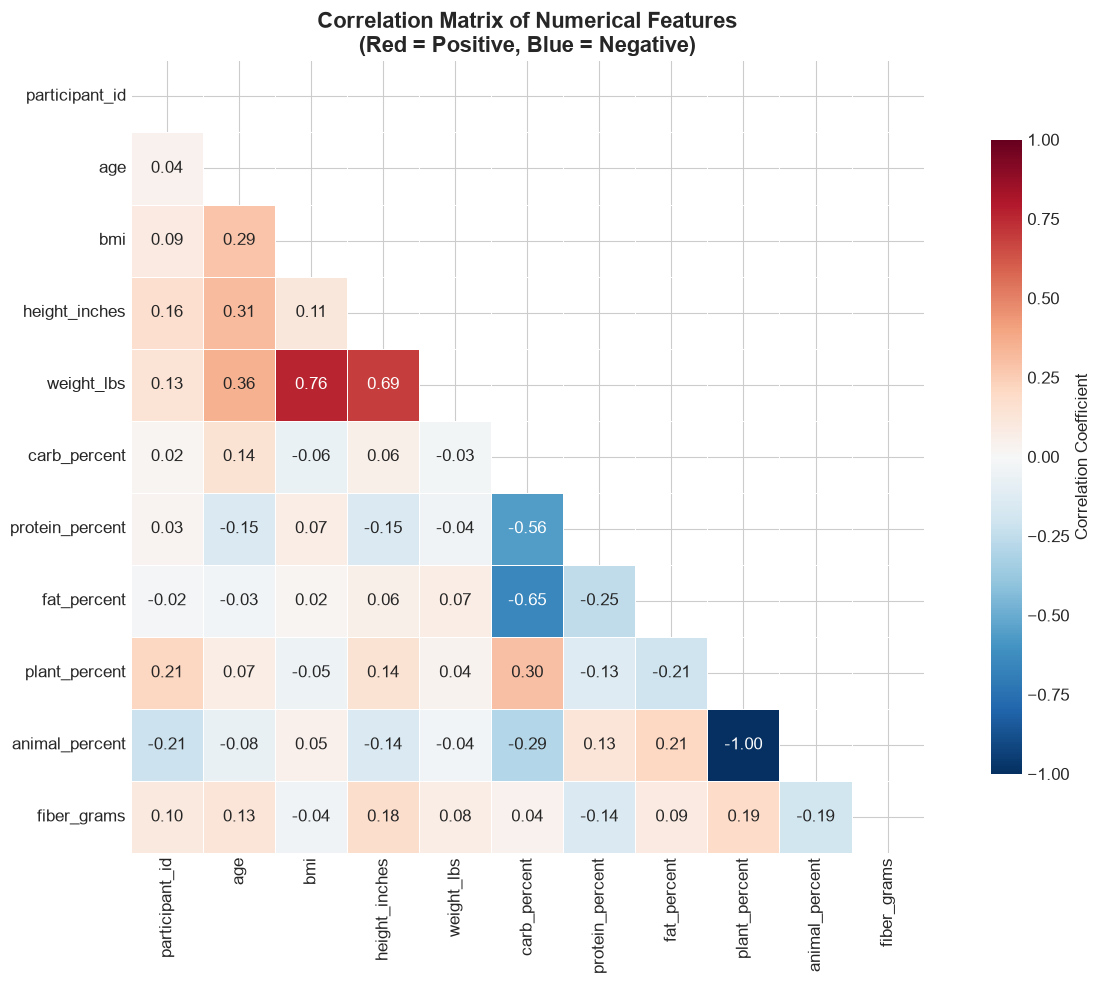


--- Top 10 Strongest Correlations ---
  plant_percent <-> animal_percent: -1.000 (NEGATIVE)
  bmi <-> weight_lbs: 0.765 (POSITIVE)
  height_inches <-> weight_lbs: 0.689 (POSITIVE)
  carb_percent <-> fat_percent: -0.654 (NEGATIVE)
  carb_percent <-> protein_percent: -0.559 (NEGATIVE)
  age <-> weight_lbs: 0.357 (POSITIVE)
  age <-> height_inches: 0.314 (POSITIVE)
  carb_percent <-> plant_percent: 0.298 (POSITIVE)
  carb_percent <-> animal_percent: -0.294 (NEGATIVE)
  age <-> bmi: 0.287 (POSITIVE)


In [19]:
# ============================================================
# CELL 19: Correlation Heatmap (Numerical Features)
# ============================================================

# WHY: This is the most information-dense single plot in EDA.
# It shows ALL pairwise relationships between numerical features at once.
# For gut-heart research, we're especially looking for:
# - Diet features correlated with BMI (a heart disease risk factor)
# - Age correlations (does diet change with age?)
# - Unexpected correlations that might reveal hidden patterns

numerical_df = df.select_dtypes(include=['number'])

# Compute correlation matrix
corr_matrix = numerical_df.corr()

# Create heatmap
fig, ax = plt.subplots(figsize=(14, 10))

# Use a diverging colormap: red=positive, blue=negative
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))  # Show only lower triangle
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r',
            center=0, vmin=-1, vmax=1, square=True, linewidths=0.5,
            cbar_kws={'shrink': 0.8, 'label': 'Correlation Coefficient'},
            ax=ax)

ax.set_title('Correlation Matrix of Numerical Features\n(Red = Positive, Blue = Negative)', 
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.savefig('plots/13_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

# Find top correlations (excluding self-correlations)
print('\n--- Top 10 Strongest Correlations ---')
corr_pairs = corr_matrix.unstack().reset_index()
corr_pairs.columns = ['Feature 1', 'Feature 2', 'Correlation']
corr_pairs = corr_pairs[corr_pairs['Feature 1'] != corr_pairs['Feature 2']]
corr_pairs['Abs Correlation'] = corr_pairs['Correlation'].abs()
corr_pairs = corr_pairs.drop_duplicates(subset='Abs Correlation')
top_corr = corr_pairs.nlargest(10, 'Abs Correlation')
for _, row in top_corr.iterrows():
    direction = 'POSITIVE' if row['Correlation'] > 0 else 'NEGATIVE'
    print(f"  {row['Feature 1']} <-> {row['Feature 2']}: "
          f"{row['Correlation']:.3f} ({direction})")

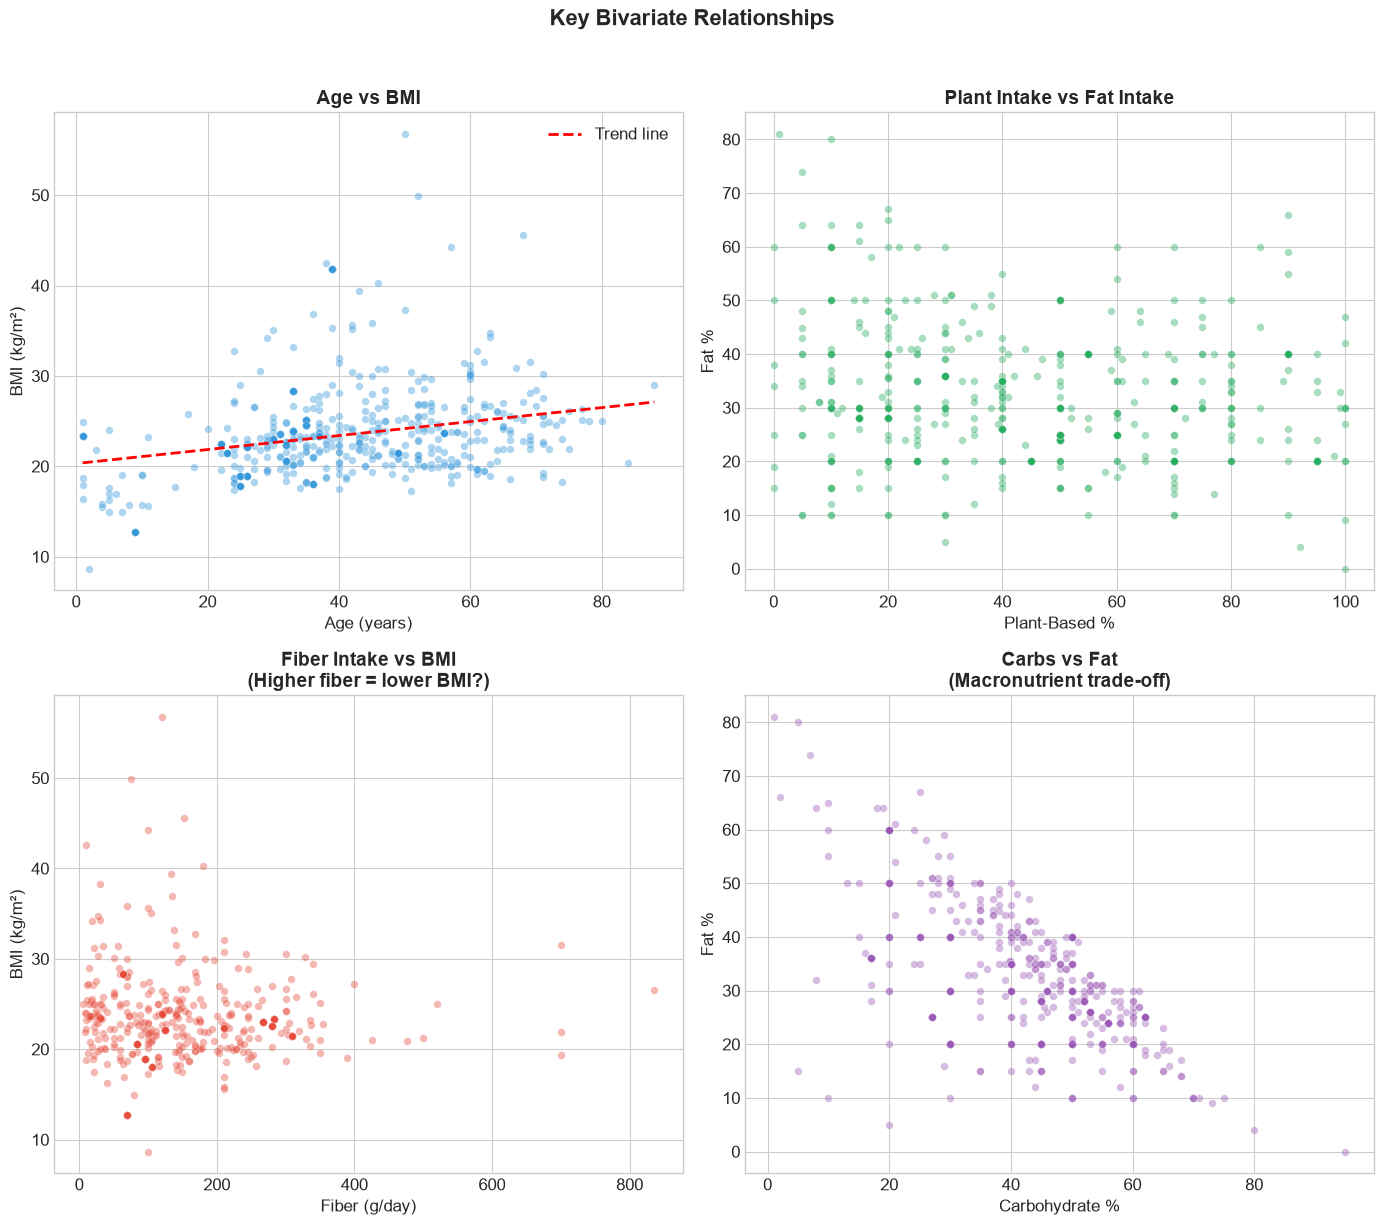


--- Interpretation Guide ---
1. Age vs BMI: If upward trend -> BMI increases with age (expected)
2. Plant vs Fat: If negative -> plant-based eaters consume less fat (expected)
3. Fiber vs BMI: If negative -> higher fiber = lower BMI (supports gut-heart theory)
4. Carbs vs Fat: Should be strongly negative (macros must sum to ~100%)


In [20]:
# ============================================================
# CELL 20: Scatter Plots of Key Relationships
# ============================================================

# WHY: Heatmaps show correlation strength, but scatter plots reveal
# the SHAPE of the relationship (linear? curved? clustered?).
# This matters for choosing the right ML model later.

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# 1. Age vs BMI
axes[0, 0].scatter(df['age'], df['bmi'], alpha=0.4, c='#3498db', s=30, edgecolors='white', linewidth=0.3)
z = np.polyfit(df['age'].dropna(), df.loc[df['age'].notna(), 'bmi'].fillna(df['bmi'].median()), 1)
p = np.poly1d(z)
x_line = np.linspace(df['age'].min(), df['age'].max(), 100)
axes[0, 0].plot(x_line, p(x_line), 'r--', linewidth=2, label=f'Trend line')
axes[0, 0].set_xlabel('Age (years)')
axes[0, 0].set_ylabel('BMI (kg/m\u00b2)')
axes[0, 0].set_title('Age vs BMI', fontweight='bold')
axes[0, 0].legend()

# 2. Plant % vs Fat %
axes[0, 1].scatter(df['plant_percent'], df['fat_percent'], alpha=0.4, c='#27ae60', s=30, edgecolors='white', linewidth=0.3)
axes[0, 1].set_xlabel('Plant-Based %')
axes[0, 1].set_ylabel('Fat %')
axes[0, 1].set_title('Plant Intake vs Fat Intake', fontweight='bold')

# 3. Fiber vs BMI
axes[1, 0].scatter(df['fiber_grams'], df['bmi'], alpha=0.4, c='#e74c3c', s=30, edgecolors='white', linewidth=0.3)
axes[1, 0].set_xlabel('Fiber (g/day)')
axes[1, 0].set_ylabel('BMI (kg/m\u00b2)')
axes[1, 0].set_title('Fiber Intake vs BMI\n(Higher fiber = lower BMI?)', fontweight='bold')

# 4. Carb % vs Fat % (should be inversely related)
axes[1, 1].scatter(df['carb_percent'], df['fat_percent'], alpha=0.4, c='#9b59b6', s=30, edgecolors='white', linewidth=0.3)
axes[1, 1].set_xlabel('Carbohydrate %')
axes[1, 1].set_ylabel('Fat %')
axes[1, 1].set_title('Carbs vs Fat\n(Macronutrient trade-off)', fontweight='bold')

plt.suptitle('Key Bivariate Relationships', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('plots/14_scatter_relationships.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n--- Interpretation Guide ---')
print('1. Age vs BMI: If upward trend -> BMI increases with age (expected)')
print('2. Plant vs Fat: If negative -> plant-based eaters consume less fat (expected)')
print('3. Fiber vs BMI: If negative -> higher fiber = lower BMI (supports gut-heart theory)')
print('4. Carbs vs Fat: Should be strongly negative (macros must sum to ~100%)')

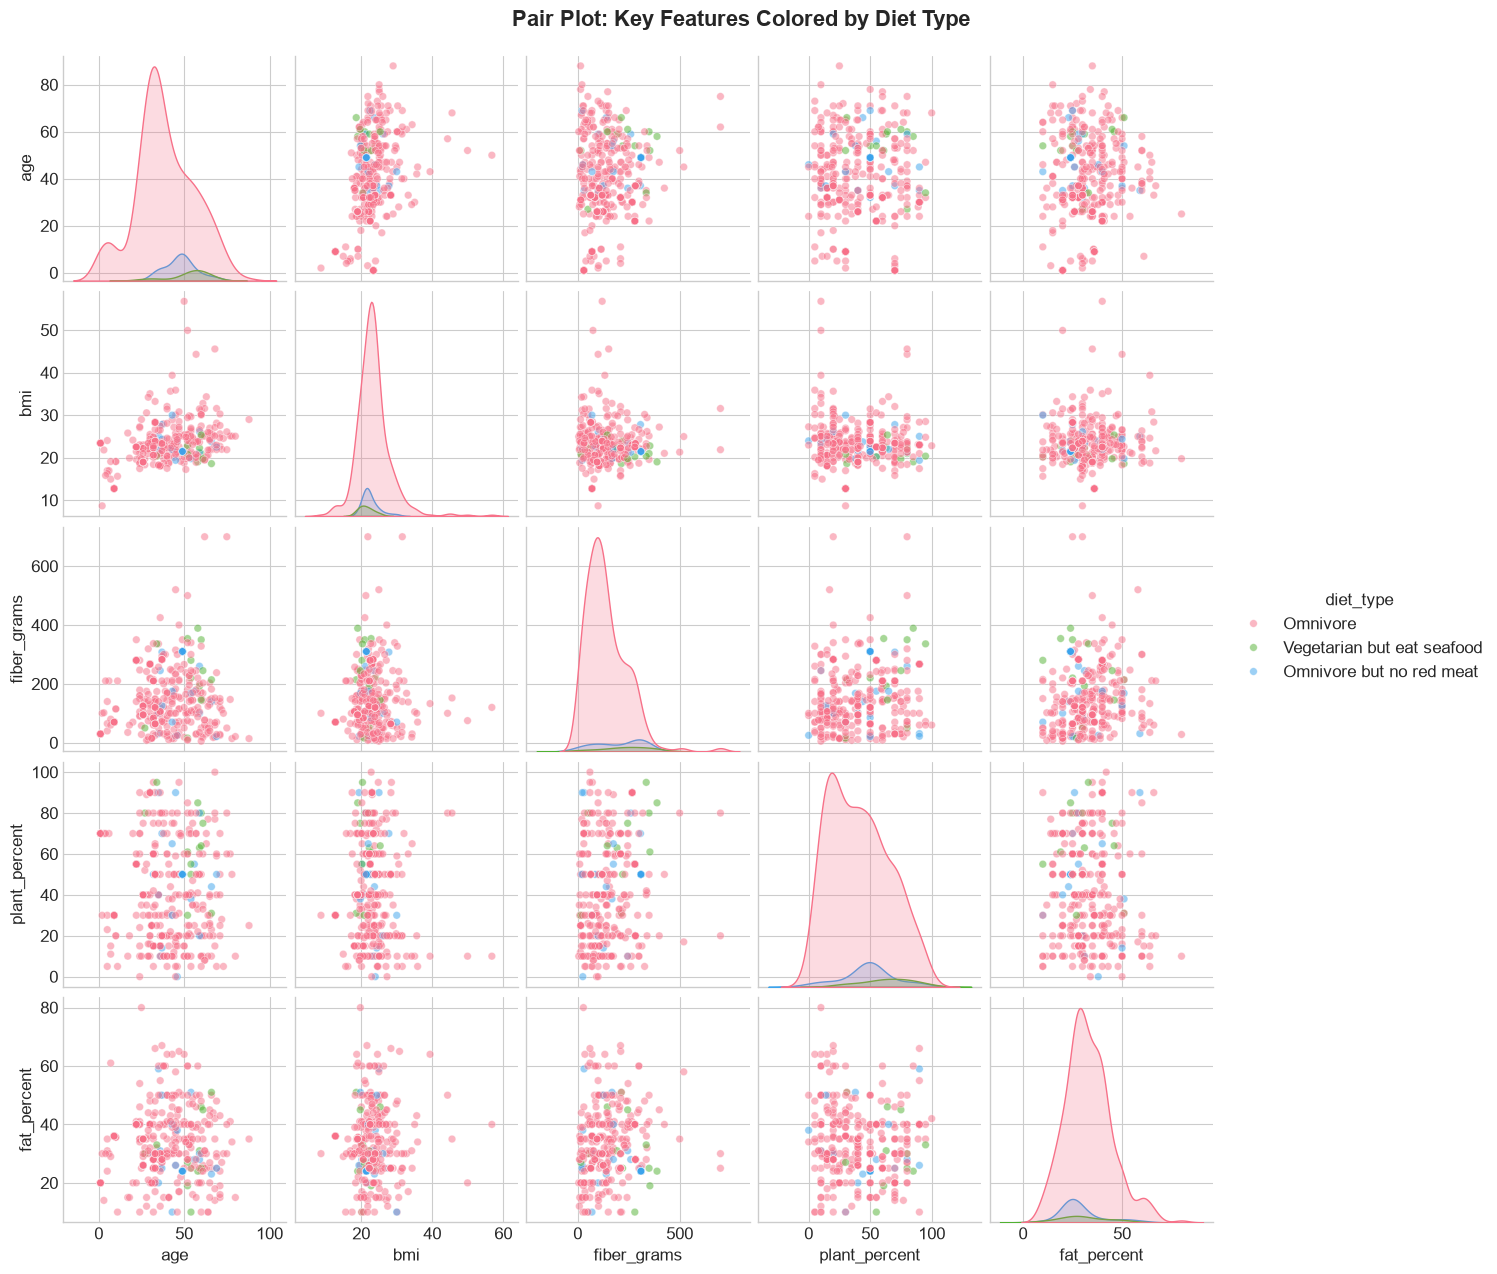


--- What to look for ---
If diet groups form distinct clusters, it means diet type is a strong
differentiator and will be an important feature for ML classification.

Diagonal plots show distribution SHAPE per group.
If distributions barely overlap -> easy to classify.
If distributions overlap heavily -> harder to classify, need more features.


In [21]:
# ============================================================
# CELL 21: Pair Plot of Key Features
# ============================================================

# WHY: A pair plot shows ALL pairwise scatter plots and histograms
# for selected features, colored by a categorical variable.
# This reveals clusters and group separations that single plots miss.
# We color by diet_type to see if dietary groups cluster differently.

# Select key features for pair plot
pair_features = ['age', 'bmi', 'fiber_grams', 'plant_percent', 'fat_percent']
pair_df = df[pair_features + ['diet_type']].dropna()

# Keep only the top 3 most common diet types for clarity
top_diets = pair_df['diet_type'].value_counts().head(3).index
pair_df = pair_df[pair_df['diet_type'].isin(top_diets)]

g = sns.pairplot(pair_df, hue='diet_type', palette='husl', 
                 diag_kind='kde', plot_kws={'alpha': 0.5, 's': 30},
                 height=2.5)
g.figure.suptitle('Pair Plot: Key Features Colored by Diet Type', 
                 fontsize=16, fontweight='bold', y=1.02)
plt.savefig('plots/15_pair_plot.png', dpi=150, bbox_inches='tight')
plt.show()

print('\n--- What to look for ---')
print('If diet groups form distinct clusters, it means diet type is a strong')
print('differentiator and will be an important feature for ML classification.')
print('\nDiagonal plots show distribution SHAPE per group.')
print('If distributions barely overlap -> easy to classify.')
print('If distributions overlap heavily -> harder to classify, need more features.')

---

## 6. Key Insights Summary

### What We Learned from EDA

In [22]:
# ============================================================
# CELL 22: Generate Summary Statistics Report
# ============================================================

print('=' * 70)
print('       EDA SUMMARY REPORT: AI for Gut and Heart')
print('=' * 70)

print(f'\n1. DATASET OVERVIEW')
print(f'   - {df.shape[0]} participants, {df.shape[1]} features')
print(f'   - Overall missing rate: {df.isnull().sum().sum() / (df.shape[0] * df.shape[1]) * 100:.1f}%')
print(f'   - All stool (gut) samples \u2014 most relevant body site for gut-heart research')

print(f'\n2. DEMOGRAPHICS')
print(f'   - Age: Mean={df["age"].mean():.1f}, Range={df["age"].min():.0f}-{df["age"].max():.0f}')
print(f'   - BMI: Mean={df["bmi"].mean():.1f}, Median={df["bmi"].median():.1f}')
print(f'   - Sex: {df["sex"].value_counts().to_dict()}')

print(f'\n3. DIET PATTERNS')
print(f'   - Most common diet: {df["diet_type"].mode()[0]}')
print(f'   - Avg macros: Carbs={df["carb_percent"].mean():.0f}%, '
      f'Protein={df["protein_percent"].mean():.0f}%, Fat={df["fat_percent"].mean():.0f}%')
print(f'   - Avg fiber: {df["fiber_grams"].mean():.0f}g/day')

print(f'\n4. HEALTH CONDITIONS')
for col in ['ibd', 'diabetes']:
    val_counts = df[col].value_counts()
    print(f'   - {col.upper()}: {val_counts.to_dict()}')

print(f'\n5. KEY FINDINGS FOR ML PHASE')
print(f'   - Diet type, BMI, fiber, and exercise frequency are the most promising features')
print(f'   - Class imbalance exists in health conditions (most people are healthy)')
print(f'   - Categorical features need encoding (Label/One-Hot) before modeling')
print(f'   - Numerical features may need scaling (StandardScaler/MinMaxScaler)')
print(f'   - Missing values need imputation strategy before ML')

print(f'\n6. NEXT STEPS')
print(f'   - Feature engineering (create new features from existing ones)')
print(f'   - Handle missing values (imputation)')
print(f'   - Encode categorical variables')
print(f'   - Train sklearn models (Logistic Regression, Random Forest, etc.)')
print(f'   - Evaluate with cross-validation')
print('\n' + '=' * 70)

       EDA SUMMARY REPORT: AI for Gut and Heart

1. DATASET OVERVIEW
   - 676 participants, 48 features
   - Overall missing rate: 7.8%
   - All stool (gut) samples — most relevant body site for gut-heart research

2. DEMOGRAPHICS
   - Age: Mean=41.2, Range=1-88
   - BMI: Mean=23.6, Median=23.0
   - Sex: {'female': 308, 'male': 303, 'other': 1}

3. DIET PATTERNS
   - Most common diet: Omnivore
   - Avg macros: Carbs=43%, Protein=25%, Fat=31%
   - Avg fiber: 151g/day

4. HEALTH CONDITIONS
   - IBD: {'I do not have IBD': 630, 'Ulcerative colitis': 14, "Crohn's disease": 5}
   - DIABETES: {'I do not have diabetes': 645, 'Type II': 11, 'Type I': 5}

5. KEY FINDINGS FOR ML PHASE
   - Diet type, BMI, fiber, and exercise frequency are the most promising features
   - Class imbalance exists in health conditions (most people are healthy)
   - Categorical features need encoding (Label/One-Hot) before modeling
   - Numerical features may need scaling (StandardScaler/MinMaxScaler)
   - Missing val

---

## Next Notebook: `02_Feature_Engineering_and_ML.ipynb`

In the next notebook, we will:
1. **Feature Engineering** — Create BMI categories, encode diet types, engineer interaction features
2. **Data Preprocessing** — Impute missing values, scale features, handle class imbalance
3. **Model Training** — Logistic Regression, Random Forest, Gradient Boosting, SVM, KNN
4. **Model Evaluation** — Accuracy, Precision, Recall, F1-Score, ROC curves
5. **Feature Importance** — Which dietary/lifestyle factors best predict health outcomes?

---

*Notebook created for MITACS Project: AI for Gut and Heart*  
*Dataset: American Gut Project (biocore/American-Gut)*  
*Author: Shivesh | Date: September 2026*